# exploring the data in the 2011 household survey

*question: Predict: Will this household miss mortage payments in next 12 months?*

#### Set up

In [1]:
import pandas
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats  

In [2]:
%matplotlib inline

In [3]:
df = pandas.read_excel("boe-nmg-household-survey-data-2004-11.xlsx", sheet_name="2011")

In [4]:
df.head(20)

,1,2,3,4,5,6,7,8,9,10,...,235,236,237,238,239,240,241,242,243,244
0,id,weight,year,sex,age,age_grp,region,gor,mastat,hushop,...,forebeareffsec,brrise,forebearunsec1,forebearunsec2,forebearunsec3,forebearunsec4,forebearunsec5,forebeareffunsec,uncert,uncertch
1,65,0.549,2011,female,29,25-34,North West,north west,never married,yes,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,vague idea,no change
2,231,3.233,2011,female,43,35-44,North West,east midlands,marrried or couple,no,...,NaN,NaN,no,no,no,no,yes,NaN,good idea,no change
3,1543,0.886,2011,female,53,45-54,Yorks&Humber,yorks and humbr,marrried or couple,no,...,NaN,NaN,no,no,no,no,yes,NaN,good idea,less certain
4,644,1.332,2011,female,36,35-44,South West,south west,marrried or couple,no,...,NaN,£200-299,no,no,no,no,yes,NaN,good idea,no change
5,108,0.877,2011,male,63,55-64,Wales,south west,marrried or couple,yes,...,NaN,NaN,no,no,no,no,yes,NaN,good idea,no change
6,1081,1.091,2011,male,41,35-44,South East,eastern,never married,no,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,don't know,don't know
7,522,0.713,2011,female,75,65+,E Midlands,south east,marrried or couple,yes,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,good idea,no change
8,1454,0.646,2011,male,83,65+,Scotland,scotland,widowed/divorced/separated,yes,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,vague idea,no change
9,364,0.708,2011,male,38,35-44,Wales,wales,marrried or couple,yes,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,good idea,no change


#### 🔎 set the column titles

In [5]:
# assume df's first row contains the desired column names
df.columns = df.iloc[0]              # Select first row as new column names
#df.iloc[0] selects row with index 0 as a Series: ['id', 'name', 'age'].

# Assigning this to df.columns replaces the old column labels (0, 1, 2) with ('id', 'name', 'age')

df = df[1:].reset_index(drop=True)   # drop the first row, fix index
# df[1:] slices the DataFrame from row index 1 onward, so the old header row (index 0) is removed.

# .reset_index(drop=True) rebuilds the index as 0, 1, 2, ... instead of keeping the old row numbers.


In [6]:
pandas.set_option("display.max_columns", None) 
df.head(2)

,id,weight,year,sex,age,age_grp,region,gor,mastat,hushop,hhsize,lstage,nkids,parent,ch03,ch45,ch69,ch1015,qual,jbstat,jbrgsc,hoh,jbstathoh,fihhyr2,fihhyr_a,dfihhyr,dfihhyr_a,dfihhyrchg,dfihhyrchg_a,us,ustot,ustot_a,ustot_grp5,ustoty_a,ustotdy_a,ustoty_grp5,ustotdy_grp5,xpus,xpus_a,xpusy_a,xpusy_grp5,usn,usa,usb,usc,usd,use,usg,ush,usi,usj,tenure,tenure_grp2,tenure_grp3,huresp,hsval,hsval_a,reshsfall,mghave,intmg,mg1tot,mg1tot_a,mg1tot_grp5,mg1toty_a,mg1totdy_a,nequity,xpmg,xpmg_a,xpmgy_a,xpmgdy_a,xpmgy_grp5,xpmgdy_grp5,fixmg,fixmg09,fixpmg_a,fnxpmg_a,fixpmg09,fnxpmg09,changepmg,changepmg_a,fxuse1,fxuse2,fxuse3,fxuse4,fxuse5,fxuse6,pmguse1,pmguse2,pmguse3,pmguse4,pmguse5,pmguse6,pmguse7,pmguse8,xphsdf,xphpdf,billscc,xphdr1,xphdr2,xphdr3,xphdr4,xphdr5,xphdr6,xphdr7,xphdr8,xphdr9,xphdr10,xphdr11,xphdr12,xphdr13,xphdr14,xphdr15,xphdd1,xphdd2,xphdd3,xphdd4,xphdd5,xphdd6,xphdd7,xphdd8,xphdd9,xphdd10,xphdd11,xphdd12,xphdd13,xphdd14,hscntcr1,hscntcr2,hscntcr,hscrchg,saveamount,saveamount_a,saving,saving11,savebcs,savebcs1,savebcs2,savebcs3,savebcs4,savebcs5,savebcs6,savebcs7,savebcs8,savebcs9,savebcs10,savebcs11,savebcs12,savebcs13,desave11bcs1,desave11bcs2,desave11bcs3,desave11bcs4,desave11bcs5,desave11bcs6,save11bcs1,save11bcs2,save11bcs3,save11bcs4,save11bcs5,save11bcs6,save11bcs7,save11bcs8,save11bcs9,save11bcs10,save11bcs11,save11bcs12,spend,nvesttot,nvesttot_a,othassets,debtconc,debtconc_act1,debtconc_act2,debtconc_act3,debtconc_act4,debtconc_act5,debtconc_act6,debtconc_act7,chdebtconc,pubsecty,fisc_conc1,fisc_conc2,fisc_conc3,fisc_conc4,fisc_conc5,fisc_conc6,fisc_conc7,fisc_conc8,fisc_conc9,fisc_act1,fisc_act2,fisc_act3,fisc_act4,fisc_act5,fisc_act6,fisc_act7,fisc_act8,fisc_act9,fisc_impact1,fisc_impact2,fisc_impact3,fisc_impact4,fisc_impact5,fisc_impact6,fisc_impact7,fisc_impact8,fisc11_act1,fisc11_act2,fisc11_act3,fisc11_act4,fisc11_act5,fisc11_act6,fisc11_conc1,fisc11_conc2,fisc11_conc3,fisc11_conc4,fisc11_conc5,fisc11_conc6,fisc11_conc7,fisc11_conc8,fisc_likact1,fisc_likact2,fisc_likact3,fisc_likact4,fisc_likact5,fisc_likact6,forebearsec1,forebearsec2,forebearsec3,forebearsec4,forebearsec5,forebearsec6,forebearsec7,forebearsec8,forebeareffsec,brrise,forebearunsec1,forebearunsec2,forebearunsec3,forebearunsec4,forebearunsec5,forebeareffunsec,uncert,uncertch
0,65,0.549,2011,female,29,25-34,North West,north west,never married,yes,3,single,0,no,no,no,no,no,gcse/o-level/cse,unemployed,C2,yes,unemployed,don't know,don't know,don't know,don't know,don't know,NaN,no,not applicable,not applicable,not applicable,not applicable,not applicable,not applicable,not applicable,not applicable,0,not applicable,not applicable,0,no,no,no,no,no,no,no,no,no,private rented,renter,renter,not applicable,not applicable,0,NaN,no,not applicable,not applicable,0,0,not applicable,not applicable,NaN,not applicable,0,not applicable,not applicable,not applicable,not applicable,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,no,not applicable,keeping up without much difficulty,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,not applicable,not applicable,not applicable,not applicable,not applicable,not applicable,not applicable,not applicable,not applicable,not applicable,not applicable,NaN,NaN,NaN,no,no,no,easier,none,0,NaN,don't know,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,none,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,no,no,no,no,no,no,yes,no,NaN,NaN,NaN,NaN,NaN,NaN,no,no,no,no,no,no,yes,no,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,vague idea,no change
1,231,3.233,2011,female,43,35-44,North West,east midlands,marrried or couple,no,4,family,2,yes,no,no,no,yes,a-level or equivalent (=nvq3),in paid employ,B,yes,in paid employ,"£75,000-£99,999",87500,£700-£799,750,down £50-£100,-75,yes,"£2,500-2,999

#### replace all "not applicable" with nan and other values with numbers


In [7]:

df = df.replace(["not applicable", "refused", "Dont know", "don't know'", "don't know" , "Refused"], np.nan)  # or any value like 0
df.head(20)
# remove dont know and refused
# remove multiple values at once
# df["brrise"] = df["brrise"].replace(["Dont know", "Refused"], np.nan)


,id,weight,year,sex,age,age_grp,region,gor,mastat,hushop,hhsize,lstage,nkids,parent,ch03,ch45,ch69,ch1015,qual,jbstat,jbrgsc,hoh,jbstathoh,fihhyr2,fihhyr_a,dfihhyr,dfihhyr_a,dfihhyrchg,dfihhyrchg_a,us,ustot,ustot_a,ustot_grp5,ustoty_a,ustotdy_a,ustoty_grp5,ustotdy_grp5,xpus,xpus_a,xpusy_a,xpusy_grp5,usn,usa,usb,usc,usd,use,usg,ush,usi,usj,tenure,tenure_grp2,tenure_grp3,huresp,hsval,hsval_a,reshsfall,mghave,intmg,mg1tot,mg1tot_a,mg1tot_grp5,mg1toty_a,mg1totdy_a,nequity,xpmg,xpmg_a,xpmgy_a,xpmgdy_a,xpmgy_grp5,xpmgdy_grp5,fixmg,fixmg09,fixpmg_a,fnxpmg_a,fixpmg09,fnxpmg09,changepmg,changepmg_a,fxuse1,fxuse2,fxuse3,fxuse4,fxuse5,fxuse6,pmguse1,pmguse2,pmguse3,pmguse4,pmguse5,pmguse6,pmguse7,pmguse8,xphsdf,xphpdf,billscc,xphdr1,xphdr2,xphdr3,xphdr4,xphdr5,xphdr6,xphdr7,xphdr8,xphdr9,xphdr10,xphdr11,xphdr12,xphdr13,xphdr14,xphdr15,xphdd1,xphdd2,xphdd3,xphdd4,xphdd5,xphdd6,xphdd7,xphdd8,xphdd9,xphdd10,xphdd11,xphdd12,xphdd13,xphdd14,hscntcr1,hscntcr2,hscntcr,hscrchg,saveamount,saveamount_a,saving,saving11,savebcs,savebcs1,savebcs2,savebcs3,savebcs4,savebcs5,savebcs6,savebcs7,savebcs8,savebcs9,savebcs10,savebcs11,savebcs12,savebcs13,desave11bcs1,desave11bcs2,desave11bcs3,desave11bcs4,desave11bcs5,desave11bcs6,save11bcs1,save11bcs2,save11bcs3,save11bcs4,save11bcs5,save11bcs6,save11bcs7,save11bcs8,save11bcs9,save11bcs10,save11bcs11,save11bcs12,spend,nvesttot,nvesttot_a,othassets,debtconc,debtconc_act1,debtconc_act2,debtconc_act3,debtconc_act4,debtconc_act5,debtconc_act6,debtconc_act7,chdebtconc,pubsecty,fisc_conc1,fisc_conc2,fisc_conc3,fisc_conc4,fisc_conc5,fisc_conc6,fisc_conc7,fisc_conc8,fisc_conc9,fisc_act1,fisc_act2,fisc_act3,fisc_act4,fisc_act5,fisc_act6,fisc_act7,fisc_act8,fisc_act9,fisc_impact1,fisc_impact2,fisc_impact3,fisc_impact4,fisc_impact5,fisc_impact6,fisc_impact7,fisc_impact8,fisc11_act1,fisc11_act2,fisc11_act3,fisc11_act4,fisc11_act5,fisc11_act6,fisc11_conc1,fisc11_conc2,fisc11_conc3,fisc11_conc4,fisc11_conc5,fisc11_conc6,fisc11_conc7,fisc11_conc8,fisc_likact1,fisc_likact2,fisc_likact3,fisc_likact4,fisc_likact5,fisc_likact6,forebearsec1,forebearsec2,forebearsec3,forebearsec4,forebearsec5,forebearsec6,forebearsec7,forebearsec8,forebeareffsec,brrise,forebearunsec1,forebearunsec2,forebearunsec3,forebearunsec4,forebearunsec5,forebeareffunsec,uncert,uncertch
0,65,0.549,2011,female,29,25-34,North West,north west,never married,yes,3,single,0,no,no,no,no,no,gcse/o-level/cse,unemployed,C2,yes,unemployed,NaN,NaN,NaN,NaN,NaN,NaN,no,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,0,no,no,no,no,no,no,no,no,no,private rented,renter,renter,NaN,NaN,0,NaN,no,NaN,NaN,0,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,no,NaN,keeping up without much difficulty,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,no,no,no,easier,none,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,none,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,no,no,no,no,no,no,yes,no,NaN,NaN,NaN,NaN,NaN,NaN,no,no,no,no,no,no,yes,no,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,vague idea,no change
1,231,3.233,2011,female,43,35-44,North West,east midlands,marrried or couple,no,4,family,2,yes,no,no,no,yes,a-level or equivalent (=nvq3),in paid employ,B,yes,in paid employ,"£75,000-£99,999",87500,£700-£799,750,down £50-£100,-75,yes,"£2,500-2,999",2750,"£1,000-£4,999",0.031429,0.305556,<0.25,0.25-0.5,£230-£239,475,0.065143,0.05-0.1,1,no,no,yes,no,no,no,no,no,no,mortgagor,owner,mortgagor,yes,"£100,000-£109,999",212500,NaN,yes,fixed,"£50,000-£59,999",55000,"£30,000-£59,999",0.628571,6.111111,NaN,"£1,250-£1,499",1375,0.188571,1.833333,0.1-0.2,>0.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,no,somewhat,

#### find the midpoint of brrise

In [8]:

df["brrise"] = df["brrise"].replace("£1500 or more", "£1500-1500")

#  Extract both endpoints from the range

    # handle the "£"  using str.extract() with regex
    # Handle "or more" cases (e.g., "£6 or more") directly with .str.extract() since it captures the number before text
df['cleaned_start_num'] = df['brrise'].str.extract(r'(\d+)', expand=False)  # Extracts first number
df['cleaned_end_num'] = df['brrise'].str.extract(r'(\d+$)', expand=False)  # Extracts last number if its there

 # dropna() here returns a new Series with NaN values removed and leaves df["cleaned_start_num"] unchanged because you are not assigning the result back to the DataFrame and you are not using any in-place modification


#compute the midpoint

# col_type = df["cleaned_start_num"].dtype
# print(col_type)

# col_type = df["cleaned_end_num"].dtype
# print(col_type)

# Step 1: Replace NaN with 0 (or other sentinel value)
df[["cleaned_start_num", "cleaned_end_num"]]= df[["cleaned_start_num", "cleaned_end_num"]].fillna(0) # fillna(0) first, then convert to integer.
#replace nan with 0


df[["cleaned_start_num", "cleaned_end_num"]] = df[["cleaned_start_num", "cleaned_end_num"]].astype("int64")
df["brrise_midpoint"] = (df["cleaned_start_num"] + df["cleaned_end_num"]) / 2

#df["brrise_midpoint"].head(20)
#delete the start and end columns just made
df = df.drop(columns=['cleaned_start_num', 'cleaned_end_num'])   



#### 🗑️DROP useless columns 

In [9]:
#TODO: maybe delete this cell 
# #delete all columns [fihhyr2, dfihhyr, ustot, xpus, hsval, mg1tot, xpmg, fixpmg_a, changepmg, saveamount, nvesttot, brrise(but find the mid point first)	]  and delete age-group
# to deeal with the ranges i cna just use the midpoint of the range
# us column is key

##### deleted string type range valies i.e £0-500

In [10]:
# deleted string type range valies i.e £0-500
df =df.drop(columns=["fihhyr2", "dfihhyrchg", "dfihhyr", "ustot", "xpus", "hsval", "mg1tot", "xpmg", "fixpmg_a", "changepmg", "saveamount", "nvesttot", "brrise", "age_grp"]) # deleted string type range valies i.e £0-500


##### deleting columns that end in "_grp5"

In [11]:
#check if there are columns that end in _grp5. y i want to deleted them? this columns are define the grpup that the value is in. i.e £1,000-£4,999
# grp5_cols = [col for col in df.columns if col.endswith('_grp5')]
# print(f"Columns to drop: {grp5_cols}")


#could be a MultiIndex (tuple column names), not simple strings. That's why endswith() fails on tuples.
print("Column structure:", type(df.columns)) # output: Column structure: <class 'pandas.Index'>. so it isn't a MultiIndex
print("Sample columns:", list(df.columns[:5]), "\n\n")


#some individual column names in that Index are tuples (probably from Excel sheet structure).
# Find which columns are tuples
tuple_cols = [col for col in df.columns if isinstance(col, tuple)]
print("Tuple columns:", tuple_cols) # yes, some are tuples
print("First few columns:", list(df.columns[:10]))


# Convert everything to strings first
df.columns = [str(col) if isinstance(col, tuple) else col for col in df.columns]

# # Now it works normally
# #check if there are columns that end in _grp5. y i want to deleted them? this columns are define the grpup that the value is in. i.e £1,000-£4,999
grp5_cols = [col for col in df.columns if col.endswith('_grp5')]
print(f"Columns to joii with the ones in the above subjection: {grp5_cols}")
# ⭐⭐⭐`#to add the groups df = df.drop(columns=grp5_cols)

# #check if the deleted columns are in the dataframe
# checker = [True if  col.endswith('_grp5') else False for col in df.columns] # gets u a super long list, which makes it hard to evaluate
# unique_count = len(set(checker)) # count the number of unique elements in a list
# print(unique_count) #output: 1, there is only one type of outcome and its False as seen if you print checker. so it is deleted



Column structure: <class 'pandas.Index'>
Sample columns: ['id', 'weight', 'year', 'sex', 'age'] 


Tuple columns: []
First few columns: ['id', 'weight', 'year', 'sex', 'age', 'region', 'gor', 'mastat', 'hushop', 'hhsize']
Columns to joii with the ones in the above subjection: ['ustot_grp5', 'ustoty_grp5', 'ustotdy_grp5', 'xpusy_grp5', 'mg1tot_grp5', 'xpmgy_grp5', 'xpmgdy_grp5']


#### conevert the right columns to integers


In [12]:
df.head(2)

,id,weight,year,sex,age,region,gor,mastat,hushop,hhsize,lstage,nkids,parent,ch03,ch45,ch69,ch1015,qual,jbstat,jbrgsc,hoh,jbstathoh,fihhyr_a,dfihhyr_a,dfihhyrchg_a,us,ustot_a,ustot_grp5,ustoty_a,ustotdy_a,ustoty_grp5,ustotdy_grp5,xpus_a,xpusy_a,xpusy_grp5,usn,usa,usb,usc,usd,use,usg,ush,usi,usj,tenure,tenure_grp2,tenure_grp3,huresp,hsval_a,reshsfall,mghave,intmg,mg1tot_a,mg1tot_grp5,mg1toty_a,mg1totdy_a,nequity,xpmg_a,xpmgy_a,xpmgdy_a,xpmgy_grp5,xpmgdy_grp5,fixmg,fixmg09,fnxpmg_a,fixpmg09,fnxpmg09,changepmg_a,fxuse1,fxuse2,fxuse3,fxuse4,fxuse5,fxuse6,pmguse1,pmguse2,pmguse3,pmguse4,pmguse5,pmguse6,pmguse7,pmguse8,xphsdf,xphpdf,billscc,xphdr1,xphdr2,xphdr3,xphdr4,xphdr5,xphdr6,xphdr7,xphdr8,xphdr9,xphdr10,xphdr11,xphdr12,xphdr13,xphdr14,xphdr15,xphdd1,xphdd2,xphdd3,xphdd4,xphdd5,xphdd6,xphdd7,xphdd8,xphdd9,xphdd10,xphdd11,xphdd12,xphdd13,xphdd14,hscntcr1,hscntcr2,hscntcr,hscrchg,saveamount_a,saving,saving11,savebcs,savebcs1,savebcs2,savebcs3,savebcs4,savebcs5,savebcs6,savebcs7,savebcs8,savebcs9,savebcs10,savebcs11,savebcs12,savebcs13,desave11bcs1,desave11bcs2,desave11bcs3,desave11bcs4,desave11bcs5,desave11bcs6,save11bcs1,save11bcs2,save11bcs3,save11bcs4,save11bcs5,save11bcs6,save11bcs7,save11bcs8,save11bcs9,save11bcs10,save11bcs11,save11bcs12,spend,nvesttot_a,othassets,debtconc,debtconc_act1,debtconc_act2,debtconc_act3,debtconc_act4,debtconc_act5,debtconc_act6,debtconc_act7,chdebtconc,pubsecty,fisc_conc1,fisc_conc2,fisc_conc3,fisc_conc4,fisc_conc5,fisc_conc6,fisc_conc7,fisc_conc8,fisc_conc9,fisc_act1,fisc_act2,fisc_act3,fisc_act4,fisc_act5,fisc_act6,fisc_act7,fisc_act8,fisc_act9,fisc_impact1,fisc_impact2,fisc_impact3,fisc_impact4,fisc_impact5,fisc_impact6,fisc_impact7,fisc_impact8,fisc11_act1,fisc11_act2,fisc11_act3,fisc11_act4,fisc11_act5,fisc11_act6,fisc11_conc1,fisc11_conc2,fisc11_conc3,fisc11_conc4,fisc11_conc5,fisc11_conc6,fisc11_conc7,fisc11_conc8,fisc_likact1,fisc_likact2,fisc_likact3,fisc_likact4,fisc_likact5,fisc_likact6,forebearsec1,forebearsec2,forebearsec3,forebearsec4,forebearsec5,forebearsec6,forebearsec7,forebearsec8,forebeareffsec,forebearunsec1,forebearunsec2,forebearunsec3,forebearunsec4,forebearunsec5,forebeareffunsec,uncert,uncertch,brrise_midpoint
0,65,0.549,2011,female,29,North West,north west,never married,yes,3,single,0,no,no,no,no,no,gcse/o-level/cse,unemployed,C2,yes,unemployed,NaN,NaN,NaN,no,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,0,no,no,no,no,no,no,no,no,no,private rented,renter,renter,NaN,0,NaN,no,NaN,0,0,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,no,NaN,keeping up without much difficulty,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,no,no,no,easier,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,no,no,no,no,no,no,yes,no,NaN,NaN,NaN,NaN,NaN,NaN,no,no,no,no,no,no,yes,no,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,vague idea,no change,0.0
1,231,3.233,2011,female,43,North West,east midlands,marrried or couple,no,4,family,2,yes,no,no,no,yes,a-level or equivalent (=nvq3),in paid employ,B,yes,in paid employ,87500,750,-75,yes,2750,"£1,000-£4,999",0.031429,0.305556,<0.25,0.25-0.5,475,0.065143,0.05-0.1,1,no,no,yes,no,no,no,no,no,no,mortgagor,owner,mortgagor,yes,212500,NaN,yes,fixed,55000,"£30,000-£59,999",0.628571,6.111111,NaN,1375,0.188571,1.833333,0.1-0.2,>0.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,no,somewhat,keeping up without much difficulty,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,no,no,no,the same,175,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

In [13]:
#df.head(20)

# choose cols to nomalise. all the ones with the midpoint of of the midrange columns 
col_norm=["weight", "usn", "dfihhyrchg_a", "fihhyr_a", "ustot_a", "ustoty_a", "ustotdy_a", "xpus_a", "xpusy_a", "hsval_a", "mg1tot_a", "mg1toty_a",	"mg1totdy_a", "xpmg_a",	"xpmgy_a", "xpmgdy_a", "saveamount_a", "nvesttot_a", "brrise_midpoint"]

#TODO:change the type of this columns
#some of those columns are numeric but contain either NaNs, floats with decimal parts, or strings like "don't know", so pandas refuses to cast them directly to int64 or similar.

def clean_numeric(col):
    # 1) Normalise special strings like "don't know" to NaN
    col = col.replace({"don't know": np.nan})

    # 2) Convert everything possible to numeric
    col = pandas.to_numeric(col, errors="coerce")

    return col

for c in col_norm:
    df[c] = clean_numeric(df[c]).astype("Float64")


df[["year", "age"]] = df[["year", "age"]].astype("Int64") # i want age to the in a whole number 

In [14]:
# let's check
df.head(20)
print(df.dtypes.value_counts())



str        199
Float64     19
object      11
Int64        2
Name: count, dtype: int64


##### just checking if what the object columns are about incase they cause me issues in the future

In [15]:
# Select only object columns and show first 20 rows
object_cols = df.select_dtypes(include=[object]).columns
print(object_cols)


string_cols = df.select_dtypes(include=[str]).columns
print(string_cols)


int_cols = df.select_dtypes(include=[int]).columns
print(int_cols)

print(df.columns)
#print(df[object_cols].head(20)) # they are the ones with yes, no or some text as values


Index(['id', 'sex', 'region', 'gor', 'mastat', 'hushop', 'hhsize', 'lstage',
       'nkids', 'parent',
       ...
       'forebearsec8', 'forebeareffsec', 'forebearunsec1', 'forebearunsec2',
       'forebearunsec3', 'forebearunsec4', 'forebearunsec5',
       'forebeareffunsec', 'uncert', 'uncertch'],
      dtype='str', length=210)
Index(['sex', 'region', 'gor', 'mastat', 'hushop', 'lstage', 'parent', 'ch03',
       'ch45', 'ch69',
       ...
       'forebearsec8', 'forebeareffsec', 'forebearunsec1', 'forebearunsec2',
       'forebearunsec3', 'forebearunsec4', 'forebearunsec5',
       'forebeareffunsec', 'uncert', 'uncertch'],
      dtype='str', length=199)
Index(['year', 'age'], dtype='str')
Index(['id', 'weight', 'year', 'sex', 'age', 'region', 'gor', 'mastat',
       'hushop', 'hhsize',
       ...
       'forebeareffsec', 'forebearunsec1', 'forebearunsec2', 'forebearunsec3',
       'forebearunsec4', 'forebearunsec5', 'forebeareffunsec', 'uncert',
       'uncertch', 'brrise_midpoint']

C:\Users\ranun\AppData\Local\Temp\ipykernel_7092\1398352685.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  object_cols = df.select_dtypes(include=[object]).columns


#### normalise columns

##### I want to see the distribution of ages. if it is skewed then i will add it to the normalised column list

> Remeber

> The range of values that z-score gives is -3 to 3


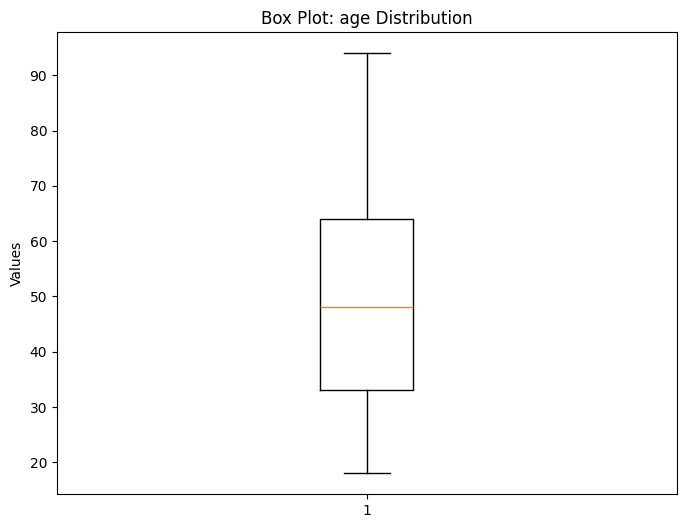

In [16]:

plt.figure(figsize=(8, 6))
plt.boxplot(df['age'].dropna())  # dropna() removes NaNs
plt.title('Box Plot: age Distribution')
plt.ylabel('Values')
plt.show()

# RESULT: there are more applicants that are older do it gets added to the list



##### Z-score normalization using sklearn cause it handles the Nans(preserves them) 

In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df[col_norm] = scaler.fit_transform(df[col_norm])

#HOW IT WORKS:
# fit_transform() is a convenience method in scikit-learn that does two things at once:
    # fit() - Learns the parameters (mean + std dev for StandardScaler)
    # transform() - Applies the scaling using those learned parameters

##### let's check if it works


In [18]:
df.head(20)

,id,weight,year,sex,age,region,gor,mastat,hushop,hhsize,lstage,nkids,parent,ch03,ch45,ch69,ch1015,qual,jbstat,jbrgsc,hoh,jbstathoh,fihhyr_a,dfihhyr_a,dfihhyrchg_a,us,ustot_a,ustot_grp5,ustoty_a,ustotdy_a,ustoty_grp5,ustotdy_grp5,xpus_a,xpusy_a,xpusy_grp5,usn,usa,usb,usc,usd,use,usg,ush,usi,usj,tenure,tenure_grp2,tenure_grp3,huresp,hsval_a,reshsfall,mghave,intmg,mg1tot_a,mg1tot_grp5,mg1toty_a,mg1totdy_a,nequity,xpmg_a,xpmgy_a,xpmgdy_a,xpmgy_grp5,xpmgdy_grp5,fixmg,fixmg09,fnxpmg_a,fixpmg09,fnxpmg09,changepmg_a,fxuse1,fxuse2,fxuse3,fxuse4,fxuse5,fxuse6,pmguse1,pmguse2,pmguse3,pmguse4,pmguse5,pmguse6,pmguse7,pmguse8,xphsdf,xphpdf,billscc,xphdr1,xphdr2,xphdr3,xphdr4,xphdr5,xphdr6,xphdr7,xphdr8,xphdr9,xphdr10,xphdr11,xphdr12,xphdr13,xphdr14,xphdr15,xphdd1,xphdd2,xphdd3,xphdd4,xphdd5,xphdd6,xphdd7,xphdd8,xphdd9,xphdd10,xphdd11,xphdd12,xphdd13,xphdd14,hscntcr1,hscntcr2,hscntcr,hscrchg,saveamount_a,saving,saving11,savebcs,savebcs1,savebcs2,savebcs3,savebcs4,savebcs5,savebcs6,savebcs7,savebcs8,savebcs9,savebcs10,savebcs11,savebcs12,savebcs13,desave11bcs1,desave11bcs2,desave11bcs3,desave11bcs4,desave11bcs5,desave11bcs6,save11bcs1,save11bcs2,save11bcs3,save11bcs4,save11bcs5,save11bcs6,save11bcs7,save11bcs8,save11bcs9,save11bcs10,save11bcs11,save11bcs12,spend,nvesttot_a,othassets,debtconc,debtconc_act1,debtconc_act2,debtconc_act3,debtconc_act4,debtconc_act5,debtconc_act6,debtconc_act7,chdebtconc,pubsecty,fisc_conc1,fisc_conc2,fisc_conc3,fisc_conc4,fisc_conc5,fisc_conc6,fisc_conc7,fisc_conc8,fisc_conc9,fisc_act1,fisc_act2,fisc_act3,fisc_act4,fisc_act5,fisc_act6,fisc_act7,fisc_act8,fisc_act9,fisc_impact1,fisc_impact2,fisc_impact3,fisc_impact4,fisc_impact5,fisc_impact6,fisc_impact7,fisc_impact8,fisc11_act1,fisc11_act2,fisc11_act3,fisc11_act4,fisc11_act5,fisc11_act6,fisc11_conc1,fisc11_conc2,fisc11_conc3,fisc11_conc4,fisc11_conc5,fisc11_conc6,fisc11_conc7,fisc11_conc8,fisc_likact1,fisc_likact2,fisc_likact3,fisc_likact4,fisc_likact5,fisc_likact6,forebearsec1,forebearsec2,forebearsec3,forebearsec4,forebearsec5,forebearsec6,forebearsec7,forebearsec8,forebeareffsec,forebearunsec1,forebearunsec2,forebearunsec3,forebearunsec4,forebearunsec5,forebeareffunsec,uncert,uncertch,brrise_midpoint
0,65,-0.966669,2011,female,29,North West,north west,never married,yes,3,single,0,no,no,no,no,no,gcse/o-level/cse,unemployed,C2,yes,unemployed,NaN,NaN,NaN,no,NaN,NaN,NaN,NaN,NaN,NaN,-0.534693,NaN,NaN,-0.767959,no,no,no,no,no,no,no,no,no,private rented,renter,renter,NaN,-0.558249,NaN,no,NaN,-0.354361,0,NaN,NaN,NaN,-0.412843,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,no,NaN,keeping up without much difficulty,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,no,no,no,easier,-0.428350,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.483770,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,no,no,no,no,no,no,yes,no,NaN,NaN,NaN,NaN,NaN,NaN,no,no,no,no,no,no,yes,no,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,vague idea,no change,-0.210481
1,231,5.105132,2011,female,43,North West,east midlands,marrried or couple,no,4,family,2,yes,no,no,no,yes,a-level or equivalent (=nvq3),in paid employ,B,yes,in paid employ,2.120481,750,-0.350647,yes,-0.327007,"£1,000-£4,999",-0.234515,-0.222152,<0.25,0.25-0.5,2.833743,0.120105,0.05-0.1,0.132515,no,no,yes,no,no,no,no,no,no,mortgagor,owner,mortgagor,yes,0.783706,NaN,yes,fixed,0.589279,"£30,000-£59,999",-0.061527,0.021991,NaN,4.344657,0.863958,1.007357,0.1-0.2,>0.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,no,somewhat,keeping up without much difficulty,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,no,no,no,the same,0.055719,

#### 🔥TODO: (complete later) drop irrelvant rows - the target y still exits at this point

In [19]:
df.head(5)

,id,weight,year,sex,age,region,gor,mastat,hushop,hhsize,lstage,nkids,parent,ch03,ch45,ch69,ch1015,qual,jbstat,jbrgsc,hoh,jbstathoh,fihhyr_a,dfihhyr_a,dfihhyrchg_a,us,ustot_a,ustot_grp5,ustoty_a,ustotdy_a,ustoty_grp5,ustotdy_grp5,xpus_a,xpusy_a,xpusy_grp5,usn,usa,usb,usc,usd,use,usg,ush,usi,usj,tenure,tenure_grp2,tenure_grp3,huresp,hsval_a,reshsfall,mghave,intmg,mg1tot_a,mg1tot_grp5,mg1toty_a,mg1totdy_a,nequity,xpmg_a,xpmgy_a,xpmgdy_a,xpmgy_grp5,xpmgdy_grp5,fixmg,fixmg09,fnxpmg_a,fixpmg09,fnxpmg09,changepmg_a,fxuse1,fxuse2,fxuse3,fxuse4,fxuse5,fxuse6,pmguse1,pmguse2,pmguse3,pmguse4,pmguse5,pmguse6,pmguse7,pmguse8,xphsdf,xphpdf,billscc,xphdr1,xphdr2,xphdr3,xphdr4,xphdr5,xphdr6,xphdr7,xphdr8,xphdr9,xphdr10,xphdr11,xphdr12,xphdr13,xphdr14,xphdr15,xphdd1,xphdd2,xphdd3,xphdd4,xphdd5,xphdd6,xphdd7,xphdd8,xphdd9,xphdd10,xphdd11,xphdd12,xphdd13,xphdd14,hscntcr1,hscntcr2,hscntcr,hscrchg,saveamount_a,saving,saving11,savebcs,savebcs1,savebcs2,savebcs3,savebcs4,savebcs5,savebcs6,savebcs7,savebcs8,savebcs9,savebcs10,savebcs11,savebcs12,savebcs13,desave11bcs1,desave11bcs2,desave11bcs3,desave11bcs4,desave11bcs5,desave11bcs6,save11bcs1,save11bcs2,save11bcs3,save11bcs4,save11bcs5,save11bcs6,save11bcs7,save11bcs8,save11bcs9,save11bcs10,save11bcs11,save11bcs12,spend,nvesttot_a,othassets,debtconc,debtconc_act1,debtconc_act2,debtconc_act3,debtconc_act4,debtconc_act5,debtconc_act6,debtconc_act7,chdebtconc,pubsecty,fisc_conc1,fisc_conc2,fisc_conc3,fisc_conc4,fisc_conc5,fisc_conc6,fisc_conc7,fisc_conc8,fisc_conc9,fisc_act1,fisc_act2,fisc_act3,fisc_act4,fisc_act5,fisc_act6,fisc_act7,fisc_act8,fisc_act9,fisc_impact1,fisc_impact2,fisc_impact3,fisc_impact4,fisc_impact5,fisc_impact6,fisc_impact7,fisc_impact8,fisc11_act1,fisc11_act2,fisc11_act3,fisc11_act4,fisc11_act5,fisc11_act6,fisc11_conc1,fisc11_conc2,fisc11_conc3,fisc11_conc4,fisc11_conc5,fisc11_conc6,fisc11_conc7,fisc11_conc8,fisc_likact1,fisc_likact2,fisc_likact3,fisc_likact4,fisc_likact5,fisc_likact6,forebearsec1,forebearsec2,forebearsec3,forebearsec4,forebearsec5,forebearsec6,forebearsec7,forebearsec8,forebeareffsec,forebearunsec1,forebearunsec2,forebearunsec3,forebearunsec4,forebearunsec5,forebeareffunsec,uncert,uncertch,brrise_midpoint
0,65,-0.966669,2011,female,29,North West,north west,never married,yes,3,single,0,no,no,no,no,no,gcse/o-level/cse,unemployed,C2,yes,unemployed,NaN,NaN,NaN,no,NaN,NaN,NaN,NaN,NaN,NaN,-0.534693,NaN,NaN,-0.767959,no,no,no,no,no,no,no,no,no,private rented,renter,renter,NaN,-0.558249,NaN,no,NaN,-0.354361,0,NaN,NaN,NaN,-0.412843,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,no,NaN,keeping up without much difficulty,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,no,no,no,easier,-0.428350,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.483770,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,no,no,no,no,no,no,yes,no,NaN,NaN,NaN,NaN,NaN,NaN,no,no,no,no,no,no,yes,no,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,vague idea,no change,-0.210481
1,231,5.105132,2011,female,43,North West,east midlands,marrried or couple,no,4,family,2,yes,no,no,no,yes,a-level or equivalent (=nvq3),in paid employ,B,yes,in paid employ,2.120481,750,-0.350647,yes,-0.327007,"£1,000-£4,999",-0.234515,-0.222152,<0.25,0.25-0.5,2.833743,0.120105,0.05-0.1,0.132515,no,no,yes,no,no,no,no,no,no,mortgagor,owner,mortgagor,yes,0.783706,NaN,yes,fixed,0.589279,"£30,000-£59,999",-0.061527,0.021991,NaN,4.344657,0.863958,1.007357,0.1-0.2,>0.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,no,somewhat,keeping up without much difficulty,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,no,no,no,the same,0.055719,

In [20]:
# delete all rows that are not mortagor
# keep only rows where column 'col' == 'some_value'
# df = df[df['tenure'] == 'Mortgagor'] # the house has a mortage

mask = df.loc[df['tenure'] == 'mortgagor']
mask = df.loc[df['mghave'] == 'yes']
#mask = df.loc[df['fixmg'] == 'no']
df = mask

# print(len(df_filtered)

In [21]:
df.head(5)

,id,weight,year,sex,age,region,gor,mastat,hushop,hhsize,lstage,nkids,parent,ch03,ch45,ch69,ch1015,qual,jbstat,jbrgsc,hoh,jbstathoh,fihhyr_a,dfihhyr_a,dfihhyrchg_a,us,ustot_a,ustot_grp5,ustoty_a,ustotdy_a,ustoty_grp5,ustotdy_grp5,xpus_a,xpusy_a,xpusy_grp5,usn,usa,usb,usc,usd,use,usg,ush,usi,usj,tenure,tenure_grp2,tenure_grp3,huresp,hsval_a,reshsfall,mghave,intmg,mg1tot_a,mg1tot_grp5,mg1toty_a,mg1totdy_a,nequity,xpmg_a,xpmgy_a,xpmgdy_a,xpmgy_grp5,xpmgdy_grp5,fixmg,fixmg09,fnxpmg_a,fixpmg09,fnxpmg09,changepmg_a,fxuse1,fxuse2,fxuse3,fxuse4,fxuse5,fxuse6,pmguse1,pmguse2,pmguse3,pmguse4,pmguse5,pmguse6,pmguse7,pmguse8,xphsdf,xphpdf,billscc,xphdr1,xphdr2,xphdr3,xphdr4,xphdr5,xphdr6,xphdr7,xphdr8,xphdr9,xphdr10,xphdr11,xphdr12,xphdr13,xphdr14,xphdr15,xphdd1,xphdd2,xphdd3,xphdd4,xphdd5,xphdd6,xphdd7,xphdd8,xphdd9,xphdd10,xphdd11,xphdd12,xphdd13,xphdd14,hscntcr1,hscntcr2,hscntcr,hscrchg,saveamount_a,saving,saving11,savebcs,savebcs1,savebcs2,savebcs3,savebcs4,savebcs5,savebcs6,savebcs7,savebcs8,savebcs9,savebcs10,savebcs11,savebcs12,savebcs13,desave11bcs1,desave11bcs2,desave11bcs3,desave11bcs4,desave11bcs5,desave11bcs6,save11bcs1,save11bcs2,save11bcs3,save11bcs4,save11bcs5,save11bcs6,save11bcs7,save11bcs8,save11bcs9,save11bcs10,save11bcs11,save11bcs12,spend,nvesttot_a,othassets,debtconc,debtconc_act1,debtconc_act2,debtconc_act3,debtconc_act4,debtconc_act5,debtconc_act6,debtconc_act7,chdebtconc,pubsecty,fisc_conc1,fisc_conc2,fisc_conc3,fisc_conc4,fisc_conc5,fisc_conc6,fisc_conc7,fisc_conc8,fisc_conc9,fisc_act1,fisc_act2,fisc_act3,fisc_act4,fisc_act5,fisc_act6,fisc_act7,fisc_act8,fisc_act9,fisc_impact1,fisc_impact2,fisc_impact3,fisc_impact4,fisc_impact5,fisc_impact6,fisc_impact7,fisc_impact8,fisc11_act1,fisc11_act2,fisc11_act3,fisc11_act4,fisc11_act5,fisc11_act6,fisc11_conc1,fisc11_conc2,fisc11_conc3,fisc11_conc4,fisc11_conc5,fisc11_conc6,fisc11_conc7,fisc11_conc8,fisc_likact1,fisc_likact2,fisc_likact3,fisc_likact4,fisc_likact5,fisc_likact6,forebearsec1,forebearsec2,forebearsec3,forebearsec4,forebearsec5,forebearsec6,forebearsec7,forebearsec8,forebeareffsec,forebearunsec1,forebearunsec2,forebearunsec3,forebearunsec4,forebearunsec5,forebeareffunsec,uncert,uncertch,brrise_midpoint
1,231,5.105132,2011,female,43,North West,east midlands,marrried or couple,no,4,family,2,yes,no,no,no,yes,a-level or equivalent (=nvq3),in paid employ,B,yes,in paid employ,2.120481,750,-0.350647,yes,-0.327007,"£1,000-£4,999",-0.234515,-0.222152,<0.25,0.25-0.5,2.833743,0.120105,0.05-0.1,0.132515,no,no,yes,no,no,no,no,no,no,mortgagor,owner,mortgagor,yes,0.783706,NaN,yes,fixed,0.589279,"£30,000-£59,999",-0.061527,0.021991,NaN,4.344657,0.863958,1.007357,0.1-0.2,>0.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,no,somewhat,keeping up without much difficulty,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,no,no,no,the same,0.055719,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.483770,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,no,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,no,no,no,no,no,yes,no,no,NaN,NaN,NaN,NaN,NaN,NaN,no,yes,no,no,no,no,no,no,no,no,yes,no,no,no,no,no,no,no,no,no,no,yes,NaN,no,no,no,no,yes,NaN,good idea,no change,-0.210481
2,1543,-0.204301,2011,female,53,Yorks&Humber,yorks and humbr,marrried or couple,no,2,post family,0,no,no,no,no,no,no formal qualifications,in paid employ,C2,yes,in paid employ,-0.063691,350,-1.286794,yes,0.103151,"£5,000-£9,999",0.134103,0.202243,<0.25,>1,0.812681,0.252570,0.05-0.1,0.132515,yes,no,no,no,no,no,no,no,no,mortgagor,owner,mortgagor,yes,0.467952,NaN,yes,fixed,0.074567,"<£30,000",0.067621,0.012784,NaN,0.884657,0.702203,0.455348,0.1-0.2,>0.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,no,somewhat,falling behind on some,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

#### one-hot encode multiple categorical nobject columns.

In [22]:
# list of categorical columns

columns_to_be_encoded = ['sex', 'hhsize','region', 'gor',  'mastat', 'hushop', 'lstage', 'nkids', 'parent', 'ch03', 'ch45', 'ch69', 'ch1015',
                         'qual', 'jbstat', 'jbrgsc', 'hoh',	'jbstathoh', 'us', "usa", "usb", "usc", "usd", "use", "usg", "ush", "usi", "usj", "tenure",
                         'tenure_grp2', 'tenure_grp3', "huresp", "reshsfall", "mghave", "intmg", "nequity", "fixmg", "fixmg09",  "fixpmg09",
                         "fxuse1", "fxuse2", "fxuse3", "fxuse4", "fxuse5", "fxuse6", "pmguse1",  "pmguse2",  "pmguse3",  "pmguse4",   "pmguse5","pmguse6",
                         "pmguse7","pmguse8", "xphsdf", "xphpdf", "billscc", "xphdr1","xphdr2","xphdr3","xphdr4","xphdr5","xphdr6","xphdr7","xphdr8",
                         "xphdr9","xphdr10","xphdr11","xphdr12","xphdr14","xphdr15","xphdr13", "hscntcr1", "hscntcr2", "hscntcr", "hscrchg", "saving",
                        "saving11", "savebcs" ,"savebcs1" ,"savebcs2" ,"savebcs3" ,"savebcs4" ,"savebcs5" ,"savebcs6" ,"savebcs7" ,"savebcs8" ,"savebcs9",
                        "savebcs10" ,"savebcs11" ,"savebcs12" ,"savebcs13" ,"desave11bcs1" ,"desave11bcs2" ,"desave11bcs3" ,"desave11bcs4" ,"desave11bcs5" ,
                        "desave11bcs6" ,"save11bcs1" ,"save11bcs2" ,"save11bcs3" ,"save11bcs4" ,"save11bcs5" ,"save11bcs6" ,"save11bcs7" ,"save11bcs8" ,
                        "save11bcs9" ,"save11bcs10" ,"save11bcs11" ,"save11bcs12" ,"spend" ,"othassets"  ,"debtconc"   ,"debtconc_act1"  ,"debtconc_act2" ,
                        "debtconc_act3" ,"debtconc_act4" ,"debtconc_act5" ,"debtconc_act6" ,"debtconc_act7" ,"chdebtconc"  ,"pubsecty","fisc_conc1" ,
                        "fisc_conc2" ,"fisc_conc3" ,"fisc_conc4" ,"fisc_conc5" ,"fisc_conc6" ,"fisc_conc7" ,"fisc_conc8" ,"fisc_conc9" ,"fisc_act1", 
                        "fisc_act2" ,"fisc_act3" ,"fisc_act4" ,"fisc_act5" ,"fisc_act6" ,"fisc_act7" ,"fisc_act8" ,"fisc_act9" ,"fisc_impact1" ,"fisc_impact2" ,
                        "fisc_impact3" ,"fisc_impact4" ,"fisc_impact5" ,"fisc_impact6" ,"fisc_impact7" ,"fisc_impact8" ,"fisc11_act1" ,"fisc11_act2" ,
                        "fisc11_act3" ,"fisc11_act4" ,"fisc11_act5" ,"fisc11_act6" ,"fisc11_conc1" ,"fisc11_conc2" ,"fisc11_conc3" ,"fisc11_conc4" ,
                        "fisc11_conc5" ,"fisc11_conc6" ,"fisc11_conc7" ,"fisc11_conc8" ,"fisc_likact1" ,"fisc_likact2" ,"fisc_likact3" ,"fisc_likact4" ,
                        "fisc_likact5" ,"fisc_likact6" ,"forebearsec1" ,"forebearsec2" ,"forebearsec3" ,"forebearsec4" ,"forebearsec5" ,"forebearsec6" ,
                        "forebearsec7" ,"forebearsec8" ,"forebeareffsec" ,"forebearunsec1" ,"forebearunsec2" ,"forebearunsec3" ,"forebearunsec4" ,
                        "forebearunsec5" ,"forebeareffunsec" ,"uncert" ,"uncertch","xphdd1" ,"xphdd2" ,"xphdd3" ,"xphdd4" ,"xphdd5" ,"xphdd6" ,"xphdd7",
                        "xphdd10" ,"xphdd11" ,"xphdd12" ,"xphdd13" ,"xphdd14" ,"xphdd8" ,"xphdd9"    
                        ]

##### columns filled with nan, yes and no and change then to int columns filled with 1s and 0s

In [23]:
# ##DEBUG:checking for sex column

# df.columns = df.columns.str.lower()

# print("Available columns with 'sex':")
# print([col for col in df.columns if 'sex' in str(col)])

# # print("\nFirst 5 in cols_yes_no_nan:")
# # print(cols_yes_no_nan[:5])


# print("\nIs 'sex' actually in df.columns?")
# print("'sex' in df.columns: " + 'sex' in df.columns)  # Should be False cause sex doesn't exist in the DataFrame.
# print(type(df.columns))

In [24]:
#DEBUG: checking for sex column
# df.head(1)

# for c in columns_to_be_encoded:
#     print(f"{df[c].name}: {type(df[c].name)} : check if in upper or lower: {c.islower()}")
          


In [25]:
df.head(5)

,id,weight,year,sex,age,region,gor,mastat,hushop,hhsize,lstage,nkids,parent,ch03,ch45,ch69,ch1015,qual,jbstat,jbrgsc,hoh,jbstathoh,fihhyr_a,dfihhyr_a,dfihhyrchg_a,us,ustot_a,ustot_grp5,ustoty_a,ustotdy_a,ustoty_grp5,ustotdy_grp5,xpus_a,xpusy_a,xpusy_grp5,usn,usa,usb,usc,usd,use,usg,ush,usi,usj,tenure,tenure_grp2,tenure_grp3,huresp,hsval_a,reshsfall,mghave,intmg,mg1tot_a,mg1tot_grp5,mg1toty_a,mg1totdy_a,nequity,xpmg_a,xpmgy_a,xpmgdy_a,xpmgy_grp5,xpmgdy_grp5,fixmg,fixmg09,fnxpmg_a,fixpmg09,fnxpmg09,changepmg_a,fxuse1,fxuse2,fxuse3,fxuse4,fxuse5,fxuse6,pmguse1,pmguse2,pmguse3,pmguse4,pmguse5,pmguse6,pmguse7,pmguse8,xphsdf,xphpdf,billscc,xphdr1,xphdr2,xphdr3,xphdr4,xphdr5,xphdr6,xphdr7,xphdr8,xphdr9,xphdr10,xphdr11,xphdr12,xphdr13,xphdr14,xphdr15,xphdd1,xphdd2,xphdd3,xphdd4,xphdd5,xphdd6,xphdd7,xphdd8,xphdd9,xphdd10,xphdd11,xphdd12,xphdd13,xphdd14,hscntcr1,hscntcr2,hscntcr,hscrchg,saveamount_a,saving,saving11,savebcs,savebcs1,savebcs2,savebcs3,savebcs4,savebcs5,savebcs6,savebcs7,savebcs8,savebcs9,savebcs10,savebcs11,savebcs12,savebcs13,desave11bcs1,desave11bcs2,desave11bcs3,desave11bcs4,desave11bcs5,desave11bcs6,save11bcs1,save11bcs2,save11bcs3,save11bcs4,save11bcs5,save11bcs6,save11bcs7,save11bcs8,save11bcs9,save11bcs10,save11bcs11,save11bcs12,spend,nvesttot_a,othassets,debtconc,debtconc_act1,debtconc_act2,debtconc_act3,debtconc_act4,debtconc_act5,debtconc_act6,debtconc_act7,chdebtconc,pubsecty,fisc_conc1,fisc_conc2,fisc_conc3,fisc_conc4,fisc_conc5,fisc_conc6,fisc_conc7,fisc_conc8,fisc_conc9,fisc_act1,fisc_act2,fisc_act3,fisc_act4,fisc_act5,fisc_act6,fisc_act7,fisc_act8,fisc_act9,fisc_impact1,fisc_impact2,fisc_impact3,fisc_impact4,fisc_impact5,fisc_impact6,fisc_impact7,fisc_impact8,fisc11_act1,fisc11_act2,fisc11_act3,fisc11_act4,fisc11_act5,fisc11_act6,fisc11_conc1,fisc11_conc2,fisc11_conc3,fisc11_conc4,fisc11_conc5,fisc11_conc6,fisc11_conc7,fisc11_conc8,fisc_likact1,fisc_likact2,fisc_likact3,fisc_likact4,fisc_likact5,fisc_likact6,forebearsec1,forebearsec2,forebearsec3,forebearsec4,forebearsec5,forebearsec6,forebearsec7,forebearsec8,forebeareffsec,forebearunsec1,forebearunsec2,forebearunsec3,forebearunsec4,forebearunsec5,forebeareffunsec,uncert,uncertch,brrise_midpoint
1,231,5.105132,2011,female,43,North West,east midlands,marrried or couple,no,4,family,2,yes,no,no,no,yes,a-level or equivalent (=nvq3),in paid employ,B,yes,in paid employ,2.120481,750,-0.350647,yes,-0.327007,"£1,000-£4,999",-0.234515,-0.222152,<0.25,0.25-0.5,2.833743,0.120105,0.05-0.1,0.132515,no,no,yes,no,no,no,no,no,no,mortgagor,owner,mortgagor,yes,0.783706,NaN,yes,fixed,0.589279,"£30,000-£59,999",-0.061527,0.021991,NaN,4.344657,0.863958,1.007357,0.1-0.2,>0.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,no,somewhat,keeping up without much difficulty,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,no,no,no,the same,0.055719,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.483770,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,no,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,no,no,no,no,no,yes,no,no,NaN,NaN,NaN,NaN,NaN,NaN,no,yes,no,no,no,no,no,no,no,no,yes,no,no,no,no,no,no,no,no,no,no,yes,NaN,no,no,no,no,yes,NaN,good idea,no change,-0.210481
2,1543,-0.204301,2011,female,53,Yorks&Humber,yorks and humbr,marrried or couple,no,2,post family,0,no,no,no,no,no,no formal qualifications,in paid employ,C2,yes,in paid employ,-0.063691,350,-1.286794,yes,0.103151,"£5,000-£9,999",0.134103,0.202243,<0.25,>1,0.812681,0.252570,0.05-0.1,0.132515,yes,no,no,no,no,no,no,no,no,mortgagor,owner,mortgagor,yes,0.467952,NaN,yes,fixed,0.074567,"<£30,000",0.067621,0.012784,NaN,0.884657,0.702203,0.455348,0.1-0.2,>0.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,no,somewhat,falling behind on some,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

In [26]:
# select all columns that are filled with nan, yes and no.


def yes_no_nan_cols(columns: list) -> pandas.DataFrame:
    cols = []
    for c in columns:
        # get unique non‑NaN values
        vals = df[c].dropna().unique()
        
        # check that all non‑NaN values are only "yes" or "no"
        if len(vals) > 0 and set(vals).issubset({"yes", "no"}):
            cols.append(c)
    return cols

columns_yes_no_nan = yes_no_nan_cols(columns_to_be_encoded)
print(df[columns_yes_no_nan])


     hushop parent ch03 ch45 ch69 ch1015  hoh   us  usa  usb  usc  usd  use  \
1        no    yes   no   no   no    yes  yes  yes   no   no  yes   no   no   
2        no     no   no   no   no     no  yes  yes  yes   no   no   no   no   
3        no    yes  yes   no  yes     no  yes  yes   no  yes   no   no   no   
5        no     no   no   no   no     no  yes  NaN  NaN  NaN  NaN  NaN  NaN   
8       yes    yes   no   no   no    yes   no  NaN  NaN  NaN  NaN  NaN  NaN   
...     ...    ...  ...  ...  ...    ...  ...  ...  ...  ...  ...  ...  ...   
1976    yes    yes  yes   no   no     no  yes   no   no   no   no   no   no   
1979    yes     no   no   no   no     no  yes  yes   no  yes  yes   no   no   
1981    yes     no   no   no   no     no   no  yes   no  yes  yes   no   no   
1982     no     no   no   no   no     no  yes  yes  yes   no   no   no   no   
1983     no     no   no   no   no     no  yes  yes  yes  yes  yes   no   no   

      usg  ush  usi  usj huresp mghave xphsdf hscnt

In [27]:
# encode the the columns so the values are in one column and don't change the column name
# Convert yes/no to 0/1 + cast to nullable int
for col in columns_yes_no_nan:
    df[col] = (df[col] == 'yes').astype("Int64")

# The boolean comparison (df[col] == 'yes') creates a True/False Series:
# Only "yes" matches → True → 1
# Everything else ("no", NaN, etc.) → False → 0
# Int64 preserves NaN as pd.NA
#⭐


In [28]:
df[columns_yes_no_nan].head()

,hushop,parent,ch03,ch45,ch69,ch1015,hoh,us,usa,usb,usc,usd,use,usg,ush,usi,usj,huresp,mghave,xphsdf,hscntcr1,hscntcr2,hscntcr,pubsecty,fisc_impact1,fisc_impact2,fisc_impact3,fisc_impact4,fisc_impact5,fisc_impact6,fisc_impact7,fisc_impact8,fisc11_act1,fisc11_act2,fisc11_act3,fisc11_act4,fisc11_act5,fisc11_act6,fisc11_conc1,fisc11_conc2,fisc11_conc3,fisc11_conc4,fisc11_conc5,fisc11_conc6,fisc11_conc7,fisc11_conc8,fisc_likact1,fisc_likact2,fisc_likact3,fisc_likact4,fisc_likact5,fisc_likact6,forebearsec1,forebearsec2,forebearsec3,forebearsec4,forebearsec5,forebearsec6,forebearsec7,forebearsec8,forebearunsec1,forebearunsec2,forebearunsec3,forebearunsec4,forebearunsec5,xphdd1,xphdd2,xphdd3,xphdd4,xphdd5,xphdd6,xphdd7,xphdd10,xphdd11,xphdd8,xphdd9
1,0,1,0,0,0,1,1,1,0,0,1,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,1,1,1,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,1,0,0,0,0,1,0,0,0,0,0
3,0,1,1,0,1,0,1,1,0,1,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
8,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [29]:
#  Check that values in the columns are only 0 or 1

allowed = {0, 1}

for c in columns_yes_no_nan:
    unique_vals = set(df[c].dropna().unique())
    ok = unique_vals.issubset(allowed)
    print(c, "OK:" if ok else "BAD:", unique_vals)


hushop

 OK: {np.int64(0), np.int64(1)}
parent OK: {np.int64(0), np.int64(1)}
ch03 OK: {np.int64(0), np.int64(1)}
ch45 OK: {np.int64(0), np.int64(1)}
ch69 OK: {np.int64(0), np.int64(1)}
ch1015 OK: {np.int64(0), np.int64(1)}
hoh OK: {np.int64(0), np.int64(1)}
us OK: {np.int64(0), np.int64(1)}
usa OK: {np.int64(0), np.int64(1)}
usb OK: {np.int64(0), np.int64(1)}
usc OK: {np.int64(0), np.int64(1)}
usd OK: {np.int64(0), np.int64(1)}
use OK: {np.int64(0), np.int64(1)}
usg OK: {np.int64(0), np.int64(1)}
ush OK: {np.int64(0), np.int64(1)}
usi OK: {np.int64(0), np.int64(1)}
usj OK: {np.int64(0), np.int64(1)}
huresp OK: {np.int64(0), np.int64(1)}
mghave OK: {np.int64(1)}
xphsdf OK: {np.int64(0), np.int64(1)}
hscntcr1 OK: {np.int64(0), np.int64(1)}
hscntcr2 OK: {np.int64(0), np.int64(1)}
hscntcr OK: {np.int64(0), np.int64(1)}
pubsecty OK: {np.int64(0), np.int64(1)}
fisc_impact1 OK: {np.int64(0), np.int64(1)}
fisc_impact2 OK: {np.int64(0), np.int64(1)}
fisc_impact3 OK: {np.int64(0), np.int64(1)}
fisc_imp

##### dealing with the real categorical colums

In [30]:
# EXPERIMENTING WITH A SOLUTION

# dummies_df = pandas.get_dummies(df['hhsize'])
# new_columns = dummies_df.columns.tolist()
# #print(new_columns)

# new_names = {}

# dummies_df.head(2)



# dummies_df = dummies_df.rename(columns={c: 'hhsize_'+ str(c)  for c in dummies_df.columns})
# dummies_df.head(2)


# # Horizontal concatenation (append columns): Join DataFrames side by side based on index.
# df_test = pandas.concat([df, dummies_df], axis=1)

# df_test.head(2)

In [31]:
# change the list of column to minus the columns that have been encoded already

#removes columns_yes_no_nan from columns_to_be_encoded


categorical_columns_to_be_num = [x for x in columns_to_be_encoded if x not in set(columns_yes_no_nan)]
df[categorical_columns_to_be_num].head(20)  # Output: [1, 3, 5]   



,sex,hhsize,region,gor,mastat,lstage,nkids,qual,jbstat,jbrgsc,jbstathoh,tenure,tenure_grp2,tenure_grp3,reshsfall,intmg,nequity,fixmg,fixmg09,fixpmg09,fxuse1,fxuse2,fxuse3,fxuse4,fxuse5,fxuse6,pmguse1,pmguse2,pmguse3,pmguse4,pmguse5,pmguse6,pmguse7,pmguse8,xphpdf,billscc,xphdr1,xphdr2,xphdr3,xphdr4,xphdr5,xphdr6,xphdr7,xphdr8,xphdr9,xphdr10,xphdr11,xphdr12,xphdr14,xphdr15,xphdr13,hscrchg,saving,saving11,savebcs,savebcs1,savebcs2,savebcs3,savebcs4,savebcs5,savebcs6,savebcs7,savebcs8,savebcs9,savebcs10,savebcs11,savebcs12,savebcs13,desave11bcs1,desave11bcs2,desave11bcs3,desave11bcs4,desave11bcs5,desave11bcs6,save11bcs1,save11bcs2,save11bcs3,save11bcs4,save11bcs5,save11bcs6,save11bcs7,save11bcs8,save11bcs9,save11bcs10,save11bcs11,save11bcs12,spend,othassets,debtconc,debtconc_act1,debtconc_act2,debtconc_act3,debtconc_act4,debtconc_act5,debtconc_act6,debtconc_act7,chdebtconc,fisc_conc1,fisc_conc2,fisc_conc3,fisc_conc4,fisc_conc5,fisc_conc6,fisc_conc7,fisc_conc8,fisc_conc9,fisc_act1,fisc_act2,fisc_act3,fisc_act4,fisc_act5,fisc_act6,fisc_act7,fisc_act8,fisc_act9,forebeareffsec,forebeareffunsec,uncert,uncertch,xphdd12,xphdd13,xphdd14
1,female,4,North West,east midlands,marrried or couple,family,2,a-level or equivalent (=nvq3),in paid employ,B,in paid employ,mortgagor,owner,mortgagor,NaN,fixed,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,somewhat,keeping up without much difficulty,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,the same,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,good idea,no change,NaN,NaN,NaN
2,female,2,Yorks&Humber,yorks and humbr,marrried or couple,post family,0,no formal qualifications,in paid employ,C2,in paid employ,mortgagor,owner,mortgagor,NaN,fixed,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,somewhat,falling behind on some,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,harder,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,good idea,less certain,NaN,NaN,NaN
3,female,4,South West,south west,marrried or couple,family,2,vocational qualifications (=nvq1+2),in paid employ,C2,in paid employ,mortgagor,owner,mortgagor,NaN,base rate tracker,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,no,keeping up without much difficulty,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Increase by £50-£99 a month,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No,No,No,No,No,No,No,No,Yes,No,No,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,good idea,no change,NaN,NaN,NaN
5,male,2,South East,eastern,never married,post family,0,no formal qualifications,long-term sick/disab,D,long-term sick/disab,mortgagor,owner,mortgagor,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,male,4,Wales,wales,marrried or couple,family,2,bachelor degree or equivalent (=nvq4),unemployed,B,in paid employ,mortgagor,owner,mortgagor,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

In [32]:
#DEBUG - there are some columns that should have been been encoded

# not_gone_yet= ["us", "usa", "usb", "usc", "usd", "use", "usg", "ush", "usi", "usj"]

# for c in not_gone_yet:
#     unique_vals = set(df[c].dropna().unique())
#     print(c,": " ,unique_vals)

In [33]:
# list of columns to be encoded


# def one_hot_encode(columns: list, dataframe):
#     df_test = pandas.DataFrame()
#     for column in columns:
#         dummies_df_temp = pandas.get_dummies(dataframe[column])
#         new_columns_list = dummies_df.columns.tolist()
#         #"EN" means encoded

#         dummies_df_temp = dummies_df_temp.rename(columns={dummy_col: str(column)+ '_' + str(dummy_col) + "EN" for dummy_col in new_columns_list})
#         df_test = pandas.concat([df_test, dummies_df_temp], axis=1)
    
#     dataframe = pandas.concat([dataframe, df_test], axis=1)
    
#     return dataframe



def one_hot_encode(columns: list, dataframe: pandas.DataFrame) -> pandas.DataFrame:
    df_test = pandas.DataFrame(index=dataframe.index)

    for column in columns:
        dummies_df_temp = pandas.get_dummies(dataframe[column], prefix=f"{column}", prefix_sep="_", dtype=int)
        # add EN suffix
        dummies_df_temp.columns = [f"{c.replace(" ", ".")}EN" for c in dummies_df_temp.columns]
        df_test = pandas.concat([df_test, dummies_df_temp], axis=1)

    # single concat at the end
    dataframe = pandas.concat([dataframe, df_test], axis=1)
    return dataframe

df = one_hot_encode(categorical_columns_to_be_num, df)


In [34]:
df.head(2)

,id,weight,year,sex,age,region,gor,mastat,hushop,hhsize,lstage,nkids,parent,ch03,ch45,ch69,ch1015,qual,jbstat,jbrgsc,hoh,jbstathoh,fihhyr_a,dfihhyr_a,dfihhyrchg_a,us,ustot_a,ustot_grp5,ustoty_a,ustotdy_a,ustoty_grp5,ustotdy_grp5,xpus_a,xpusy_a,xpusy_grp5,usn,usa,usb,usc,usd,use,usg,ush,usi,usj,tenure,tenure_grp2,tenure_grp3,huresp,hsval_a,reshsfall,mghave,intmg,mg1tot_a,mg1tot_grp5,mg1toty_a,mg1totdy_a,nequity,xpmg_a,xpmgy_a,xpmgdy_a,xpmgy_grp5,xpmgdy_grp5,fixmg,fixmg09,fnxpmg_a,fixpmg09,fnxpmg09,changepmg_a,fxuse1,fxuse2,fxuse3,fxuse4,fxuse5,fxuse6,pmguse1,pmguse2,pmguse3,pmguse4,pmguse5,pmguse6,pmguse7,pmguse8,xphsdf,xphpdf,billscc,xphdr1,xphdr2,xphdr3,xphdr4,xphdr5,xphdr6,xphdr7,xphdr8,xphdr9,xphdr10,xphdr11,xphdr12,xphdr13,xphdr14,xphdr15,xphdd1,xphdd2,xphdd3,xphdd4,xphdd5,xphdd6,xphdd7,xphdd8,xphdd9,xphdd10,xphdd11,xphdd12,xphdd13,xphdd14,hscntcr1,hscntcr2,hscntcr,hscrchg,saveamount_a,saving,saving11,savebcs,savebcs1,savebcs2,savebcs3,savebcs4,savebcs5,savebcs6,savebcs7,savebcs8,savebcs9,savebcs10,savebcs11,savebcs12,savebcs13,desave11bcs1,desave11bcs2,desave11bcs3,desave11bcs4,desave11bcs5,desave11bcs6,save11bcs1,save11bcs2,save11bcs3,save11bcs4,save11bcs5,save11bcs6,save11bcs7,save11bcs8,save11bcs9,save11bcs10,save11bcs11,save11bcs12,spend,nvesttot_a,othassets,debtconc,debtconc_act1,debtconc_act2,debtconc_act3,debtconc_act4,debtconc_act5,debtconc_act6,debtconc_act7,chdebtconc,pubsecty,fisc_conc1,fisc_conc2,fisc_conc3,fisc_conc4,fisc_conc5,fisc_conc6,fisc_conc7,fisc_conc8,fisc_conc9,fisc_act1,fisc_act2,fisc_act3,fisc_act4,fisc_act5,fisc_act6,fisc_act7,fisc_act8,fisc_act9,fisc_impact1,fisc_impact2,fisc_impact3,fisc_impact4,fisc_impact5,fisc_impact6,fisc_impact7,fisc_impact8,fisc11_act1,fisc11_act2,fisc11_act3,fisc11_act4,fisc11_act5,fisc11_act6,fisc11_conc1,fisc11_conc2,fisc11_conc3,fisc11_conc4,fisc11_conc5,fisc11_conc6,fisc11_conc7,fisc11_conc8,fisc_likact1,fisc_likact2,fisc_likact3,fisc_likact4,fisc_likact5,fisc_likact6,forebearsec1,forebearsec2,forebearsec3,forebearsec4,forebearsec5,forebearsec6,forebearsec7,forebearsec8,forebeareffsec,forebearunsec1,forebearunsec2,forebearunsec3,forebearunsec4,forebearunsec5,forebeareffunsec,uncert,uncertch,brrise_midpoint,sex_femaleEN,sex_maleEN,hhsize_1EN,hhsize_2EN,hhsize_3EN,hhsize_4EN,hhsize_5+EN,region_E.AngliaEN,region_E.MidlandsEN,region_Greater.LondonEN,region_NorthEN,region_North.WestEN,region_ScotlandEN,region_South.EastEN,region_South.WestEN,region_W.MidlandsEN,region_WalesEN,region_Yorks&HumberEN,gor_east.midlandsEN,gor_easternEN,gor_londonEN,gor_north.eastEN,gor_north.westEN,gor_scotlandEN,gor_south.eastEN,gor_south.westEN,gor_walesEN,gor_west.midlandsEN,gor_yorks.and.humbrEN,mastat_marrried.or.coupleEN,mastat_never.marriedEN,mastat_widowed/divorced/separatedEN,lstage_familyEN,lstage_post.familyEN,lstage_pre.familyEN,lstage_singleEN,nkids_0EN,nkids_1EN,nkids_2EN,nkids_3EN,nkids_4EN,nkids_5+EN,qual_a-level.or.equivalent.(=nvq3)EN,qual_bachelor.degree.or.equivalent.(=nvq4)EN,qual_gcse/o-level/cseEN,qual_masters/phd.or.equivalentEN,qual_no.formal.qualificationsEN,qual_otherEN,qual_still.studyingEN,qual_vocational.qualifications.(=nvq1+2)EN,jbstat_FT.studentEN,jbstat_in.paid.employEN,jbstat_long-term.sick/disabEN,jbstat_retiredEN,jbstat_self.employedEN,jbstat_something.elseEN,jbstat_unemployedEN,jbrgsc_AEN,jbrgsc_BEN,jbrgsc_C1EN,jbrgsc_C2EN,jbrgsc_DEN,jbrgsc_EEN,jbstathoh_FT.studentEN,jbstathoh_in.paid.employEN,jbstathoh_long-term.sick/disabEN,jbstathoh_retiredEN,jbstathoh_self.employedEN,jbstathoh_something.elseEN,jbstathoh_unemployedEN,tenure_mortgagorEN,tenure_grp2_ownerEN,tenure_grp3_mortgagorEN,intmg_-10EN,intmg_base.rate.trackerEN,intmg_cappedEN,intmg_discountedEN,intmg_fixedEN,intmg_other.EN,intmg_variableEN,xphpdf_heavyEN,xphpdf_noEN,xphpdf_somewhatEN,billscc_falling.behind.on.someEN,"billscc_have.financial.problems,.fallen.behind.with.manyEN",billscc_keeping.up.without.much.difficultyEN,"billscc_keeping.up,.constant.struggleEN","billscc_keeping.up,.struggle.from.ti

In [35]:
# to remove those original categorical columns after one‑hot encoding:
df = df.drop(columns=columns_to_be_encoded)


In [36]:
df.head(20)

,id,weight,year,age,fihhyr_a,dfihhyr_a,dfihhyrchg_a,ustot_a,ustot_grp5,ustoty_a,ustotdy_a,ustoty_grp5,ustotdy_grp5,xpus_a,xpusy_a,xpusy_grp5,usn,hsval_a,mg1tot_a,mg1tot_grp5,mg1toty_a,mg1totdy_a,xpmg_a,xpmgy_a,xpmgdy_a,xpmgy_grp5,xpmgdy_grp5,fnxpmg_a,fnxpmg09,changepmg_a,saveamount_a,nvesttot_a,brrise_midpoint,sex_femaleEN,sex_maleEN,hhsize_1EN,hhsize_2EN,hhsize_3EN,hhsize_4EN,hhsize_5+EN,region_E.AngliaEN,region_E.MidlandsEN,region_Greater.LondonEN,region_NorthEN,region_North.WestEN,region_ScotlandEN,region_South.EastEN,region_South.WestEN,region_W.MidlandsEN,region_WalesEN,region_Yorks&HumberEN,gor_east.midlandsEN,gor_easternEN,gor_londonEN,gor_north.eastEN,gor_north.westEN,gor_scotlandEN,gor_south.eastEN,gor_south.westEN,gor_walesEN,gor_west.midlandsEN,gor_yorks.and.humbrEN,mastat_marrried.or.coupleEN,mastat_never.marriedEN,mastat_widowed/divorced/separatedEN,lstage_familyEN,lstage_post.familyEN,lstage_pre.familyEN,lstage_singleEN,nkids_0EN,nkids_1EN,nkids_2EN,nkids_3EN,nkids_4EN,nkids_5+EN,qual_a-level.or.equivalent.(=nvq3)EN,qual_bachelor.degree.or.equivalent.(=nvq4)EN,qual_gcse/o-level/cseEN,qual_masters/phd.or.equivalentEN,qual_no.formal.qualificationsEN,qual_otherEN,qual_still.studyingEN,qual_vocational.qualifications.(=nvq1+2)EN,jbstat_FT.studentEN,jbstat_in.paid.employEN,jbstat_long-term.sick/disabEN,jbstat_retiredEN,jbstat_self.employedEN,jbstat_something.elseEN,jbstat_unemployedEN,jbrgsc_AEN,jbrgsc_BEN,jbrgsc_C1EN,jbrgsc_C2EN,jbrgsc_DEN,jbrgsc_EEN,jbstathoh_FT.studentEN,jbstathoh_in.paid.employEN,jbstathoh_long-term.sick/disabEN,jbstathoh_retiredEN,jbstathoh_self.employedEN,jbstathoh_something.elseEN,jbstathoh_unemployedEN,tenure_mortgagorEN,tenure_grp2_ownerEN,tenure_grp3_mortgagorEN,intmg_-10EN,intmg_base.rate.trackerEN,intmg_cappedEN,intmg_discountedEN,intmg_fixedEN,intmg_other.EN,intmg_variableEN,xphpdf_heavyEN,xphpdf_noEN,xphpdf_somewhatEN,billscc_falling.behind.on.someEN,"billscc_have.financial.problems,.fallen.behind.with.manyEN",billscc_keeping.up.without.much.difficultyEN,"billscc_keeping.up,.constant.struggleEN","billscc_keeping.up,.struggle.from.time.to.timeEN",hscrchg_easierEN,hscrchg_harderEN,hscrchg_the.sameEN,saving11_Decrease.by.less.than.£50.a.monthEN,saving11_Decrease.by.£100-£149.a.monthEN,saving11_Decrease.by.£150-£199.a.monthEN,saving11_Decrease.by.£200-£299.a.monthEN,saving11_Decrease.by.£300.or.more.a.monthEN,saving11_Decrease.by.£50-£99.a.monthEN,saving11_Don’t.plan.to.change.my.monthly.savingsEN,saving11_Increase.by.less.than.£50.a.monthEN,saving11_Increase.by.£100-£149.a.monthEN,saving11_Increase.by.£150-£199.a.monthEN,saving11_Increase.by.£200-£299.a.monthEN,saving11_Increase.by.£300.or.more.a.monthEN,saving11_Increase.by.£50-£99.a.monthEN,desave11bcs1_NoEN,desave11bcs1_YesEN,desave11bcs2_NoEN,desave11bcs2_YesEN,desave11bcs3_NoEN,desave11bcs3_YesEN,desave11bcs4_NoEN,desave11bcs4_YesEN,desave11bcs5_NoEN,desave11bcs5_YesEN,desave11bcs6_NoEN,desave11bcs6_YesEN,save11bcs1_NoEN,save11bcs1_YesEN,save11bcs2_NoEN,save11bcs2_YesEN,save11bcs3_NoEN,save11bcs3_YesEN,save11bcs4_NoEN,save11bcs4_YesEN,save11bcs5_NoEN,save11bcs5_YesEN,save11bcs6_NoEN,save11bcs6_YesEN,save11bcs7_NoEN,save11bcs7_YesEN,save11bcs8_NoEN,save11bcs8_YesEN,save11bcs9_NoEN,save11bcs9_YesEN,save11bcs10_NoEN,save11bcs10_YesEN,save11bcs11_NoEN,save11bcs11_YesEN,save11bcs12_NoEN,save11bcs12_YesEN,forebeareffsec_I.would.be.behind.on.my.mortgage.payments.by.6.months.or.more.of.payments.EN,forebeareffsec_I.would.be.behind.on.my.mortgage.payments.by.less.than.6.months.of.paymentsEN,"forebeareffsec_I.would.be.up.to.date.with.my.mortgage.payments,.but.it.would.be.a.struggleEN","forebeareffsec_I.would.be.up.to.date.with.my.mortgage.payments,.without.much.struggle..EN",forebeareffunsec_I.would.be.behind.on.my.loan.paymentsEN,"forebeareffunsec_I.would.be.up.to.date.with.my.loan.payments,.but.it.would.be.a.struggleEN","forebeareffunsec_I.would.be.up.to.date.with.my.loan.payments,.without.much.struggle..EN",uncert_good.ideaEN,uncert_no.ideaEN,u

### delete the left over columns

In [37]:
#df =df.drop(columns=categorical_columns_to_be_num)

In [38]:
df.head()

,id,weight,year,age,fihhyr_a,dfihhyr_a,dfihhyrchg_a,ustot_a,ustot_grp5,ustoty_a,ustotdy_a,ustoty_grp5,ustotdy_grp5,xpus_a,xpusy_a,xpusy_grp5,usn,hsval_a,mg1tot_a,mg1tot_grp5,mg1toty_a,mg1totdy_a,xpmg_a,xpmgy_a,xpmgdy_a,xpmgy_grp5,xpmgdy_grp5,fnxpmg_a,fnxpmg09,changepmg_a,saveamount_a,nvesttot_a,brrise_midpoint,sex_femaleEN,sex_maleEN,hhsize_1EN,hhsize_2EN,hhsize_3EN,hhsize_4EN,hhsize_5+EN,region_E.AngliaEN,region_E.MidlandsEN,region_Greater.LondonEN,region_NorthEN,region_North.WestEN,region_ScotlandEN,region_South.EastEN,region_South.WestEN,region_W.MidlandsEN,region_WalesEN,region_Yorks&HumberEN,gor_east.midlandsEN,gor_easternEN,gor_londonEN,gor_north.eastEN,gor_north.westEN,gor_scotlandEN,gor_south.eastEN,gor_south.westEN,gor_walesEN,gor_west.midlandsEN,gor_yorks.and.humbrEN,mastat_marrried.or.coupleEN,mastat_never.marriedEN,mastat_widowed/divorced/separatedEN,lstage_familyEN,lstage_post.familyEN,lstage_pre.familyEN,lstage_singleEN,nkids_0EN,nkids_1EN,nkids_2EN,nkids_3EN,nkids_4EN,nkids_5+EN,qual_a-level.or.equivalent.(=nvq3)EN,qual_bachelor.degree.or.equivalent.(=nvq4)EN,qual_gcse/o-level/cseEN,qual_masters/phd.or.equivalentEN,qual_no.formal.qualificationsEN,qual_otherEN,qual_still.studyingEN,qual_vocational.qualifications.(=nvq1+2)EN,jbstat_FT.studentEN,jbstat_in.paid.employEN,jbstat_long-term.sick/disabEN,jbstat_retiredEN,jbstat_self.employedEN,jbstat_something.elseEN,jbstat_unemployedEN,jbrgsc_AEN,jbrgsc_BEN,jbrgsc_C1EN,jbrgsc_C2EN,jbrgsc_DEN,jbrgsc_EEN,jbstathoh_FT.studentEN,jbstathoh_in.paid.employEN,jbstathoh_long-term.sick/disabEN,jbstathoh_retiredEN,jbstathoh_self.employedEN,jbstathoh_something.elseEN,jbstathoh_unemployedEN,tenure_mortgagorEN,tenure_grp2_ownerEN,tenure_grp3_mortgagorEN,intmg_-10EN,intmg_base.rate.trackerEN,intmg_cappedEN,intmg_discountedEN,intmg_fixedEN,intmg_other.EN,intmg_variableEN,xphpdf_heavyEN,xphpdf_noEN,xphpdf_somewhatEN,billscc_falling.behind.on.someEN,"billscc_have.financial.problems,.fallen.behind.with.manyEN",billscc_keeping.up.without.much.difficultyEN,"billscc_keeping.up,.constant.struggleEN","billscc_keeping.up,.struggle.from.time.to.timeEN",hscrchg_easierEN,hscrchg_harderEN,hscrchg_the.sameEN,saving11_Decrease.by.less.than.£50.a.monthEN,saving11_Decrease.by.£100-£149.a.monthEN,saving11_Decrease.by.£150-£199.a.monthEN,saving11_Decrease.by.£200-£299.a.monthEN,saving11_Decrease.by.£300.or.more.a.monthEN,saving11_Decrease.by.£50-£99.a.monthEN,saving11_Don’t.plan.to.change.my.monthly.savingsEN,saving11_Increase.by.less.than.£50.a.monthEN,saving11_Increase.by.£100-£149.a.monthEN,saving11_Increase.by.£150-£199.a.monthEN,saving11_Increase.by.£200-£299.a.monthEN,saving11_Increase.by.£300.or.more.a.monthEN,saving11_Increase.by.£50-£99.a.monthEN,desave11bcs1_NoEN,desave11bcs1_YesEN,desave11bcs2_NoEN,desave11bcs2_YesEN,desave11bcs3_NoEN,desave11bcs3_YesEN,desave11bcs4_NoEN,desave11bcs4_YesEN,desave11bcs5_NoEN,desave11bcs5_YesEN,desave11bcs6_NoEN,desave11bcs6_YesEN,save11bcs1_NoEN,save11bcs1_YesEN,save11bcs2_NoEN,save11bcs2_YesEN,save11bcs3_NoEN,save11bcs3_YesEN,save11bcs4_NoEN,save11bcs4_YesEN,save11bcs5_NoEN,save11bcs5_YesEN,save11bcs6_NoEN,save11bcs6_YesEN,save11bcs7_NoEN,save11bcs7_YesEN,save11bcs8_NoEN,save11bcs8_YesEN,save11bcs9_NoEN,save11bcs9_YesEN,save11bcs10_NoEN,save11bcs10_YesEN,save11bcs11_NoEN,save11bcs11_YesEN,save11bcs12_NoEN,save11bcs12_YesEN,forebeareffsec_I.would.be.behind.on.my.mortgage.payments.by.6.months.or.more.of.payments.EN,forebeareffsec_I.would.be.behind.on.my.mortgage.payments.by.less.than.6.months.of.paymentsEN,"forebeareffsec_I.would.be.up.to.date.with.my.mortgage.payments,.but.it.would.be.a.struggleEN","forebeareffsec_I.would.be.up.to.date.with.my.mortgage.payments,.without.much.struggle..EN",forebeareffunsec_I.would.be.behind.on.my.loan.paymentsEN,"forebeareffunsec_I.would.be.up.to.date.with.my.loan.payments,.but.it.would.be.a.struggleEN","forebeareffunsec_I.would.be.up.to.date.with.my.loan.payments,.without.much.struggle..EN",uncert_good.ideaEN,uncert_no.ideaEN,u

In [39]:
df.describe()

,weight,year,age,fihhyr_a,dfihhyrchg_a,ustot_a,ustoty_a,ustotdy_a,xpus_a,xpusy_a,usn,hsval_a,mg1tot_a,mg1toty_a,mg1totdy_a,xpmg_a,xpmgy_a,xpmgdy_a,saveamount_a,nvesttot_a,brrise_midpoint,sex_femaleEN,sex_maleEN,hhsize_1EN,hhsize_2EN,hhsize_3EN,hhsize_4EN,hhsize_5+EN,region_E.AngliaEN,region_E.MidlandsEN,region_Greater.LondonEN,region_NorthEN,region_North.WestEN,region_ScotlandEN,region_South.EastEN,region_South.WestEN,region_W.MidlandsEN,region_WalesEN,region_Yorks&HumberEN,gor_east.midlandsEN,gor_easternEN,gor_londonEN,gor_north.eastEN,gor_north.westEN,gor_scotlandEN,gor_south.eastEN,gor_south.westEN,gor_walesEN,gor_west.midlandsEN,gor_yorks.and.humbrEN,mastat_marrried.or.coupleEN,mastat_never.marriedEN,mastat_widowed/divorced/separatedEN,lstage_familyEN,lstage_post.familyEN,lstage_pre.familyEN,lstage_singleEN,nkids_0EN,nkids_1EN,nkids_2EN,nkids_3EN,nkids_4EN,nkids_5+EN,qual_a-level.or.equivalent.(=nvq3)EN,qual_bachelor.degree.or.equivalent.(=nvq4)EN,qual_gcse/o-level/cseEN,qual_masters/phd.or.equivalentEN,qual_no.formal.qualificationsEN,qual_otherEN,qual_still.studyingEN,qual_vocational.qualifications.(=nvq1+2)EN,jbstat_FT.studentEN,jbstat_in.paid.employEN,jbstat_long-term.sick/disabEN,jbstat_retiredEN,jbstat_self.employedEN,jbstat_something.elseEN,jbstat_unemployedEN,jbrgsc_AEN,jbrgsc_BEN,jbrgsc_C1EN,jbrgsc_C2EN,jbrgsc_DEN,jbrgsc_EEN,jbstathoh_FT.studentEN,jbstathoh_in.paid.employEN,jbstathoh_long-term.sick/disabEN,jbstathoh_retiredEN,jbstathoh_self.employedEN,jbstathoh_something.elseEN,jbstathoh_unemployedEN,tenure_mortgagorEN,tenure_grp2_ownerEN,tenure_grp3_mortgagorEN,intmg_-10EN,intmg_base.rate.trackerEN,intmg_cappedEN,intmg_discountedEN,intmg_fixedEN,intmg_other.EN,intmg_variableEN,xphpdf_heavyEN,xphpdf_noEN,xphpdf_somewhatEN,billscc_falling.behind.on.someEN,"billscc_have.financial.problems,.fallen.behind.with.manyEN",billscc_keeping.up.without.much.difficultyEN,"billscc_keeping.up,.constant.struggleEN","billscc_keeping.up,.struggle.from.time.to.timeEN",hscrchg_easierEN,hscrchg_harderEN,hscrchg_the.sameEN,saving11_Decrease.by.less.than.£50.a.monthEN,saving11_Decrease.by.£100-£149.a.monthEN,saving11_Decrease.by.£150-£199.a.monthEN,saving11_Decrease.by.£200-£299.a.monthEN,saving11_Decrease.by.£300.or.more.a.monthEN,saving11_Decrease.by.£50-£99.a.monthEN,saving11_Don’t.plan.to.change.my.monthly.savingsEN,saving11_Increase.by.less.than.£50.a.monthEN,saving11_Increase.by.£100-£149.a.monthEN,saving11_Increase.by.£150-£199.a.monthEN,saving11_Increase.by.£200-£299.a.monthEN,saving11_Increase.by.£300.or.more.a.monthEN,saving11_Increase.by.£50-£99.a.monthEN,desave11bcs1_NoEN,desave11bcs1_YesEN,desave11bcs2_NoEN,desave11bcs2_YesEN,desave11bcs3_NoEN,desave11bcs3_YesEN,desave11bcs4_NoEN,desave11bcs4_YesEN,desave11bcs5_NoEN,desave11bcs5_YesEN,desave11bcs6_NoEN,desave11bcs6_YesEN,save11bcs1_NoEN,save11bcs1_YesEN,save11bcs2_NoEN,save11bcs2_YesEN,save11bcs3_NoEN,save11bcs3_YesEN,save11bcs4_NoEN,save11bcs4_YesEN,save11bcs5_NoEN,save11bcs5_YesEN,save11bcs6_NoEN,save11bcs6_YesEN,save11bcs7_NoEN,save11bcs7_YesEN,save11bcs8_NoEN,save11bcs8_YesEN,save11bcs9_NoEN,save11bcs9_YesEN,save11bcs10_NoEN,save11bcs10_YesEN,save11bcs11_NoEN,save11bcs11_YesEN,save11bcs12_NoEN,save11bcs12_YesEN,forebeareffsec_I.would.be.behind.on.my.mortgage.payments.by.6.months.or.more.of.payments.EN,forebeareffsec_I.would.be.behind.on.my.mortgage.payments.by.less.than.6.months.of.paymentsEN,"forebeareffsec_I.would.be.up.to.date.with.my.mortgage.payments,.but.it.would.be.a.struggleEN","forebeareffsec_I.would.be.up.to.date.with.my.mortgage.payments,.without.much.struggle..EN",forebeareffunsec_I.would.be.behind.on.my.loan.paymentsEN,"forebeareffunsec_I.would.be.up.to.date.with.my.loan.payments,.but.it.would.be.a.struggleEN","forebeareffunsec_I.would.be.up.to.date.with.my.loan.payments,.without.much.struggle..EN",uncert_good.ideaEN,uncert_no.ideaEN,uncert_vague.ideaEN,uncertch_less.certainEN,uncertch_more.certainEN,uncertch_no.changeEN
count,582.000000,582.0,581.0,382.0000

#### 🔎👓NOTE do feature crossing (join multiple related columns into one column)

# EXPLORATORY DATA ANALYSIS

Aims:
- summarise main characteristics of the data
- find the relationships betwwen columns
- find the columns that impact whether the user will miss mortage payment

##### find y value - value to predict

In [40]:
df.head()

,id,weight,year,age,fihhyr_a,dfihhyr_a,dfihhyrchg_a,ustot_a,ustot_grp5,ustoty_a,ustotdy_a,ustoty_grp5,ustotdy_grp5,xpus_a,xpusy_a,xpusy_grp5,usn,hsval_a,mg1tot_a,mg1tot_grp5,mg1toty_a,mg1totdy_a,xpmg_a,xpmgy_a,xpmgdy_a,xpmgy_grp5,xpmgdy_grp5,fnxpmg_a,fnxpmg09,changepmg_a,saveamount_a,nvesttot_a,brrise_midpoint,sex_femaleEN,sex_maleEN,hhsize_1EN,hhsize_2EN,hhsize_3EN,hhsize_4EN,hhsize_5+EN,region_E.AngliaEN,region_E.MidlandsEN,region_Greater.LondonEN,region_NorthEN,region_North.WestEN,region_ScotlandEN,region_South.EastEN,region_South.WestEN,region_W.MidlandsEN,region_WalesEN,region_Yorks&HumberEN,gor_east.midlandsEN,gor_easternEN,gor_londonEN,gor_north.eastEN,gor_north.westEN,gor_scotlandEN,gor_south.eastEN,gor_south.westEN,gor_walesEN,gor_west.midlandsEN,gor_yorks.and.humbrEN,mastat_marrried.or.coupleEN,mastat_never.marriedEN,mastat_widowed/divorced/separatedEN,lstage_familyEN,lstage_post.familyEN,lstage_pre.familyEN,lstage_singleEN,nkids_0EN,nkids_1EN,nkids_2EN,nkids_3EN,nkids_4EN,nkids_5+EN,qual_a-level.or.equivalent.(=nvq3)EN,qual_bachelor.degree.or.equivalent.(=nvq4)EN,qual_gcse/o-level/cseEN,qual_masters/phd.or.equivalentEN,qual_no.formal.qualificationsEN,qual_otherEN,qual_still.studyingEN,qual_vocational.qualifications.(=nvq1+2)EN,jbstat_FT.studentEN,jbstat_in.paid.employEN,jbstat_long-term.sick/disabEN,jbstat_retiredEN,jbstat_self.employedEN,jbstat_something.elseEN,jbstat_unemployedEN,jbrgsc_AEN,jbrgsc_BEN,jbrgsc_C1EN,jbrgsc_C2EN,jbrgsc_DEN,jbrgsc_EEN,jbstathoh_FT.studentEN,jbstathoh_in.paid.employEN,jbstathoh_long-term.sick/disabEN,jbstathoh_retiredEN,jbstathoh_self.employedEN,jbstathoh_something.elseEN,jbstathoh_unemployedEN,tenure_mortgagorEN,tenure_grp2_ownerEN,tenure_grp3_mortgagorEN,intmg_-10EN,intmg_base.rate.trackerEN,intmg_cappedEN,intmg_discountedEN,intmg_fixedEN,intmg_other.EN,intmg_variableEN,xphpdf_heavyEN,xphpdf_noEN,xphpdf_somewhatEN,billscc_falling.behind.on.someEN,"billscc_have.financial.problems,.fallen.behind.with.manyEN",billscc_keeping.up.without.much.difficultyEN,"billscc_keeping.up,.constant.struggleEN","billscc_keeping.up,.struggle.from.time.to.timeEN",hscrchg_easierEN,hscrchg_harderEN,hscrchg_the.sameEN,saving11_Decrease.by.less.than.£50.a.monthEN,saving11_Decrease.by.£100-£149.a.monthEN,saving11_Decrease.by.£150-£199.a.monthEN,saving11_Decrease.by.£200-£299.a.monthEN,saving11_Decrease.by.£300.or.more.a.monthEN,saving11_Decrease.by.£50-£99.a.monthEN,saving11_Don’t.plan.to.change.my.monthly.savingsEN,saving11_Increase.by.less.than.£50.a.monthEN,saving11_Increase.by.£100-£149.a.monthEN,saving11_Increase.by.£150-£199.a.monthEN,saving11_Increase.by.£200-£299.a.monthEN,saving11_Increase.by.£300.or.more.a.monthEN,saving11_Increase.by.£50-£99.a.monthEN,desave11bcs1_NoEN,desave11bcs1_YesEN,desave11bcs2_NoEN,desave11bcs2_YesEN,desave11bcs3_NoEN,desave11bcs3_YesEN,desave11bcs4_NoEN,desave11bcs4_YesEN,desave11bcs5_NoEN,desave11bcs5_YesEN,desave11bcs6_NoEN,desave11bcs6_YesEN,save11bcs1_NoEN,save11bcs1_YesEN,save11bcs2_NoEN,save11bcs2_YesEN,save11bcs3_NoEN,save11bcs3_YesEN,save11bcs4_NoEN,save11bcs4_YesEN,save11bcs5_NoEN,save11bcs5_YesEN,save11bcs6_NoEN,save11bcs6_YesEN,save11bcs7_NoEN,save11bcs7_YesEN,save11bcs8_NoEN,save11bcs8_YesEN,save11bcs9_NoEN,save11bcs9_YesEN,save11bcs10_NoEN,save11bcs10_YesEN,save11bcs11_NoEN,save11bcs11_YesEN,save11bcs12_NoEN,save11bcs12_YesEN,forebeareffsec_I.would.be.behind.on.my.mortgage.payments.by.6.months.or.more.of.payments.EN,forebeareffsec_I.would.be.behind.on.my.mortgage.payments.by.less.than.6.months.of.paymentsEN,"forebeareffsec_I.would.be.up.to.date.with.my.mortgage.payments,.but.it.would.be.a.struggleEN","forebeareffsec_I.would.be.up.to.date.with.my.mortgage.payments,.without.much.struggle..EN",forebeareffunsec_I.would.be.behind.on.my.loan.paymentsEN,"forebeareffunsec_I.would.be.up.to.date.with.my.loan.payments,.but.it.would.be.a.struggleEN","forebeareffunsec_I.would.be.up.to.date.with.my.loan.payments,.without.much.struggle..EN",uncert_good.ideaEN,uncert_no.ideaEN,u

In [41]:
y_column = "xphpdf_heavyEN"

#### find the pearson corroletaion and p value of all variables and select the variables that have a strong correlation

In [65]:

def find_strong_correlations(correlation_coeffient, p_value):
    correlation_coeffient_threshold = 0.4
    if ((correlation_coeffient <= - correlation_coeffient_threshold) or (correlation_coeffient >= correlation_coeffient_threshold)) and p_value < 0.001:
        return True # there is a strong correlation
    else:
        return False
        
    

##### there were duplicate columns(hhsize)

In [43]:

#The index of df has duplicates (e.g. after concat/merge without resetting index), so when pandas aligns x_clean and y_clean or when you later assign results back to df, it hits the duplicate-index restriction
# 1. Check for duplicate index
df.index.duplicated().any()

np.False_

In [44]:


# 2. Inspect which index values are duplicated
df[df.index.duplicated(keep=False)]

# 3. If you don't care about the current index, reset it
df = df.reset_index(drop=True)





In [45]:
#f you suspect duplicated column names:

df.columns.duplicated().any()

np.False_

In [46]:
df.loc[:, df.columns.duplicated(keep=False)]  # see duplicated columns

""
0
1
2
3
4
...
577
578
579
580


In [47]:
# Optionally drop duplicated columns completely:
df = df.loc[:, ~df.columns.duplicated(keep='first')]

In [48]:
df.head(1)

,id,weight,year,age,fihhyr_a,dfihhyr_a,dfihhyrchg_a,ustot_a,ustot_grp5,ustoty_a,ustotdy_a,ustoty_grp5,ustotdy_grp5,xpus_a,xpusy_a,xpusy_grp5,usn,hsval_a,mg1tot_a,mg1tot_grp5,mg1toty_a,mg1totdy_a,xpmg_a,xpmgy_a,xpmgdy_a,xpmgy_grp5,xpmgdy_grp5,fnxpmg_a,fnxpmg09,changepmg_a,saveamount_a,nvesttot_a,brrise_midpoint,sex_femaleEN,sex_maleEN,hhsize_1EN,hhsize_2EN,hhsize_3EN,hhsize_4EN,hhsize_5+EN,region_E.AngliaEN,region_E.MidlandsEN,region_Greater.LondonEN,region_NorthEN,region_North.WestEN,region_ScotlandEN,region_South.EastEN,region_South.WestEN,region_W.MidlandsEN,region_WalesEN,region_Yorks&HumberEN,gor_east.midlandsEN,gor_easternEN,gor_londonEN,gor_north.eastEN,gor_north.westEN,gor_scotlandEN,gor_south.eastEN,gor_south.westEN,gor_walesEN,gor_west.midlandsEN,gor_yorks.and.humbrEN,mastat_marrried.or.coupleEN,mastat_never.marriedEN,mastat_widowed/divorced/separatedEN,lstage_familyEN,lstage_post.familyEN,lstage_pre.familyEN,lstage_singleEN,nkids_0EN,nkids_1EN,nkids_2EN,nkids_3EN,nkids_4EN,nkids_5+EN,qual_a-level.or.equivalent.(=nvq3)EN,qual_bachelor.degree.or.equivalent.(=nvq4)EN,qual_gcse/o-level/cseEN,qual_masters/phd.or.equivalentEN,qual_no.formal.qualificationsEN,qual_otherEN,qual_still.studyingEN,qual_vocational.qualifications.(=nvq1+2)EN,jbstat_FT.studentEN,jbstat_in.paid.employEN,jbstat_long-term.sick/disabEN,jbstat_retiredEN,jbstat_self.employedEN,jbstat_something.elseEN,jbstat_unemployedEN,jbrgsc_AEN,jbrgsc_BEN,jbrgsc_C1EN,jbrgsc_C2EN,jbrgsc_DEN,jbrgsc_EEN,jbstathoh_FT.studentEN,jbstathoh_in.paid.employEN,jbstathoh_long-term.sick/disabEN,jbstathoh_retiredEN,jbstathoh_self.employedEN,jbstathoh_something.elseEN,jbstathoh_unemployedEN,tenure_mortgagorEN,tenure_grp2_ownerEN,tenure_grp3_mortgagorEN,intmg_-10EN,intmg_base.rate.trackerEN,intmg_cappedEN,intmg_discountedEN,intmg_fixedEN,intmg_other.EN,intmg_variableEN,xphpdf_heavyEN,xphpdf_noEN,xphpdf_somewhatEN,billscc_falling.behind.on.someEN,"billscc_have.financial.problems,.fallen.behind.with.manyEN",billscc_keeping.up.without.much.difficultyEN,"billscc_keeping.up,.constant.struggleEN","billscc_keeping.up,.struggle.from.time.to.timeEN",hscrchg_easierEN,hscrchg_harderEN,hscrchg_the.sameEN,saving11_Decrease.by.less.than.£50.a.monthEN,saving11_Decrease.by.£100-£149.a.monthEN,saving11_Decrease.by.£150-£199.a.monthEN,saving11_Decrease.by.£200-£299.a.monthEN,saving11_Decrease.by.£300.or.more.a.monthEN,saving11_Decrease.by.£50-£99.a.monthEN,saving11_Don’t.plan.to.change.my.monthly.savingsEN,saving11_Increase.by.less.than.£50.a.monthEN,saving11_Increase.by.£100-£149.a.monthEN,saving11_Increase.by.£150-£199.a.monthEN,saving11_Increase.by.£200-£299.a.monthEN,saving11_Increase.by.£300.or.more.a.monthEN,saving11_Increase.by.£50-£99.a.monthEN,desave11bcs1_NoEN,desave11bcs1_YesEN,desave11bcs2_NoEN,desave11bcs2_YesEN,desave11bcs3_NoEN,desave11bcs3_YesEN,desave11bcs4_NoEN,desave11bcs4_YesEN,desave11bcs5_NoEN,desave11bcs5_YesEN,desave11bcs6_NoEN,desave11bcs6_YesEN,save11bcs1_NoEN,save11bcs1_YesEN,save11bcs2_NoEN,save11bcs2_YesEN,save11bcs3_NoEN,save11bcs3_YesEN,save11bcs4_NoEN,save11bcs4_YesEN,save11bcs5_NoEN,save11bcs5_YesEN,save11bcs6_NoEN,save11bcs6_YesEN,save11bcs7_NoEN,save11bcs7_YesEN,save11bcs8_NoEN,save11bcs8_YesEN,save11bcs9_NoEN,save11bcs9_YesEN,save11bcs10_NoEN,save11bcs10_YesEN,save11bcs11_NoEN,save11bcs11_YesEN,save11bcs12_NoEN,save11bcs12_YesEN,forebeareffsec_I.would.be.behind.on.my.mortgage.payments.by.6.months.or.more.of.payments.EN,forebeareffsec_I.would.be.behind.on.my.mortgage.payments.by.less.than.6.months.of.paymentsEN,"forebeareffsec_I.would.be.up.to.date.with.my.mortgage.payments,.but.it.would.be.a.struggleEN","forebeareffsec_I.would.be.up.to.date.with.my.mortgage.payments,.without.much.struggle..EN",forebeareffunsec_I.would.be.behind.on.my.loan.paymentsEN,"forebeareffunsec_I.would.be.up.to.date.with.my.loan.payments,.but.it.would.be.a.struggleEN","forebeareffunsec_I.would.be.up.to.date.with.my.loan.payments,.without.much.struggle..EN",uncert_good.ideaEN,uncert_no.ideaEN,u

##### Continuing from were i left off

In [66]:
# strong_correlation_colum_names = []

# for column in df.columns.to_list():
#     pearson_coef, p_value= stats.pearsonr(df[str(column)], df[y_column]) # doesnt work with nan's so the nans have to be removed
#     final_correlation = find_strong_correlations(pearson_coef, p_value)
#     if final_correlation == True:
#         strong_correlation_colum_names.append(column)






# If all your columns are numeric but contain NaN/None, you need to drop or mask those missing values before calling pearsonr, and you must do it in a paired way so x and y stay aligned.

# Here is a robust pattern for your loop:





strong_correlation_column_names = []

numeric_cols = df.select_dtypes(include=[np.number]).columns

for column in numeric_cols:
    x = df[column]
    y = df['age']

    # Drop rows where either x or y is NaN
    mask = x.notna() & y.notna()
    x_clean = x[mask]
    y_clean = y[mask]

    # Need at least 2 points for pearsonr
    if len(x_clean) < 2:
        continue

    pearson_coef, p_value = stats.pearsonr(x_clean, y_clean)
    final_correlation = find_strong_correlations(pearson_coef, p_value)
    if final_correlation:
        strong_correlation_column_names.append(column)


# Key points:

    # Use select_dtypes(include=[np.number]) so you only loop over numeric columns.
    # ​

    # Use a boolean mask x.notna() & y.notna() to simultaneously remove NaN from both variables.
    # ​

    # Skip columns where, after dropping NaN, fewer than 2 valid rows remain, because pearsonr needs at least two observations.



C:\Users\ranun\AppData\Local\Temp\ipykernel_7092\464779092.py:39: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  pearson_coef, p_value = stats.pearsonr(x_clean, y_clean)
C:\Users\ranun\AppData\Local\Temp\ipykernel_7092\464779092.py:39: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  pearson_coef, p_value = stats.pearsonr(x_clean, y_clean)
C:\Users\ranun\AppData\Local\Temp\ipykernel_7092\464779092.py:39: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  pearson_coef, p_value = stats.pearsonr(x_clean, y_clean)
C:\Users\ranun\AppData\Local\Temp\ipykernel_7092\464779092.py:39: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  pearson_coef, p_value = stats.pearsonr(x_clean, y_clean)


In [67]:
print(strong_correlation_column_names)

['age', 'mastat_never.marriedEN', 'lstage_post.familyEN', 'lstage_singleEN', 'jbstat_retiredEN', 'jbstathoh_retiredEN']


In [51]:
#trying to find why there are no values
for column in numeric_cols[5:]:
    x = df[column]
    y = df['age']

    # Drop rows where either x or y is NaN
    mask = x.notna() & y.notna()
    x_clean = x[mask]
    y_clean = y[mask]
    print(f"x_clean: {x_clean}")

x_clean: 0     -0.327007
1      0.103151
2     -0.388458
5     -0.019751
6     -0.652698
         ...   
576   -0.388458
578    0.533309
579   -0.572812
580   -0.327007
581    0.348956
Name: ustot_a, Length: 306, dtype: float64
x_clean: 0     -0.234515
1      0.134103
2     -0.199560
5     -0.074080
6     -0.266781
         ...   
575   -0.126960
576    0.045126
577   -0.293669
578    0.569927
581   -0.045219
Name: ustoty_a, Length: 342, dtype: float64
x_clean: 0     -0.222152
1      0.202243
2     -0.242090
5      1.238309
6     -0.301904
         ...   
577   -0.331811
578    0.501314
579   -0.267724
580   -0.268546
581    0.047778
Name: ustotdy_a, Length: 393, dtype: float64
x_clean: 0      2.833743
1      0.812681
2      0.812681
5      0.954510
6     -0.499236
         ...   
577   -0.534693
578    1.521826
579   -0.002835
580    0.387195
581    2.124599
Name: xpus_a, Length: 450, dtype: float64
x_clean: 0      0.120105
1      0.252570
2      0.012170
5      0.051936
6     -0.3016

# MODEL DEVELOPMENT

In [ ]:
#import lib
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import train_test_split

In [84]:
X = df[strong_correlation_column_names]
Y = df[y_column]

In [85]:
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.4, random_state=0)


In [86]:
lm = HistGradientBoostingClassifier() #handles nans, decided ont to fill nans because they are too many it would definaltly skew the data
lm.fit(X_train,y_train) # train the model


,"loss loss: {'log_loss'}, default='log_loss'The loss function to use in the boosting process.For binary classification problems, 'log_loss' is also known as logistic loss,binomial deviance or binary crossentropy. Internally, the model fits one treeper boosting iteration and uses the logistic sigmoid function (expit) asinverse link function to compute the predicted positive class probability.For multiclass classification problems, 'log_loss' is also known as multinomialdeviance or categorical crossentropy. Internally, the model fits one tree perboosting iteration and per class and uses the softmax function as inverse linkfunction to compute the predicted probabilities of the classes.",'log_loss'
,"learning_rate learning_rate: float, default=0.1The learning rate, also known as *shrinkage*. This is used as amultiplicative factor for the leaves values. Use ``1`` for noshrinkage.",0.1
,"max_iter max_iter: int, default=100The maximum number of iterations of the boosting process, i.e. themaximum number of trees for binary classification. For multiclassclassification, `n_classes` trees per iteration are built.",100
,"max_leaf_nodes max_leaf_nodes: int or None, default=31The maximum number of leaves for each tree. Must be strictly greaterthan 1. If None, there is no maximum limit.",31
,"max_depth max_depth: int or None, default=NoneThe maximum depth of each tree. The depth of a tree is the number ofedges to go from the root to the deepest leaf.Depth isn't constrained by default.",None
,"min_samples_leaf min_samples_leaf: int, default=20The minimum number of samples per leaf. For small datasets with lessthan a few hundred samples, it is recommended to lower this valuesince only very shallow trees would be built.",20
,"l2_regularization l2_regularization: float, default=0The L2 regularization parameter penalizing leaves with small hessians.Use ``0`` for no regularization (default).",0.0
,"max_features max_features: float, default=1.0Proportion of randomly chosen features in each and every node split.This is a form of regularization, smaller values make the trees weakerlearners and might prevent overfitting.If interaction constraints from `interaction_cst` are present, only allowedfeatures are taken into account for the subsampling... versionadded:: 1.4",1.0
,"max_bins max_bins: int, default=255The maximum number of bins to use for non-missing values. Beforetraining, each feature of the input array `X` is binned intointeger-valued bins, which allows for a much faster training stage.Features with a small number of unique values may use less than``max_bins`` bins. In addition to the ``max_bins`` bins, one more binis always reserved for missing values. Must be no larger than 255.",255
,"categorical_features categorical_features: array-like of {bool, int, str} of shape (n_features) or shape (n_categorical_features,), default='from_dtype'Indicates the categorical features.- None : no feature will be considered categorical.- boolean array-like : boolean mask indicating categorical features.- integer array-like : integer indices indicating categorical features.- str array-like: names of categorical features (assuming the training data has feature names).- `""from_dtype""`: dataframe columns with dtype ""category"" are considered to be categorical features. The input must be an object exposing a ``__dataframe__`` method such as pandas or polars DataFrames to use this feature.For each categorical feature, there must be at most `max_bins` uniquecategories. Negative values for categorical features encoded as numericdtypes are treated as missing values. All categorical values areconverted to floating point numbers. This means that categorical valuesof 1.0 and 1 are treated as the same category.Read more in the :ref:`User Guide `... versionadded:: 0.24.. versionchanged:: 1.2 Added support for feature names... versionchanged:: 1.4 Added `""from_dtype""` option... versionchanged:: 1.6 The default value changed from `None` to `""from_dtype""`.",'from_dt

# Evaluate model

In [87]:
import seaborn as sns

A residual plot is a scatter plot that shows regression residuals (errors: actual minus predicted values) on the vertical axis against the predictor or fitted values on the horizontal axis, used to assess model fit.

<Axes: xlabel='age', ylabel='xphpdf_heavyEN'>

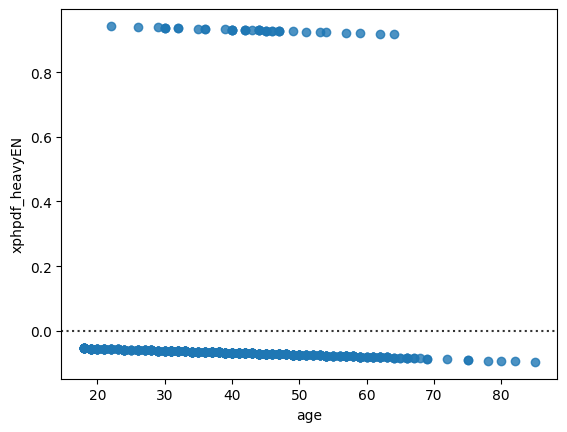

In [88]:
sns.residplot(x='age', y='xphpdf_heavyEN', data=df) # residual plot

<Axes: xlabel='mastat_never.marriedEN', ylabel='xphpdf_heavyEN'>

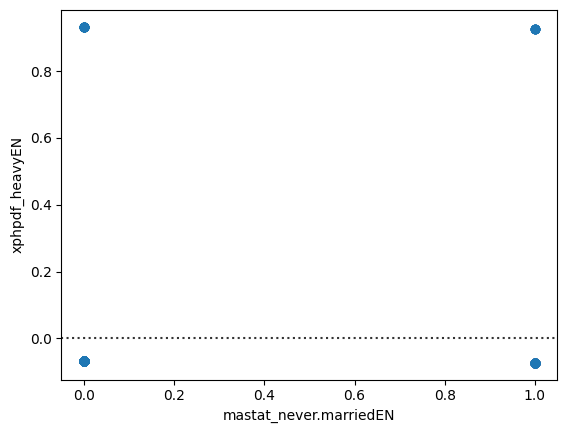

In [89]:
sns.residplot(x='mastat_never.marriedEN', y='xphpdf_heavyEN', data=df) # residual plot

<Axes: xlabel='lstage_post.familyEN', ylabel='xphpdf_heavyEN'>

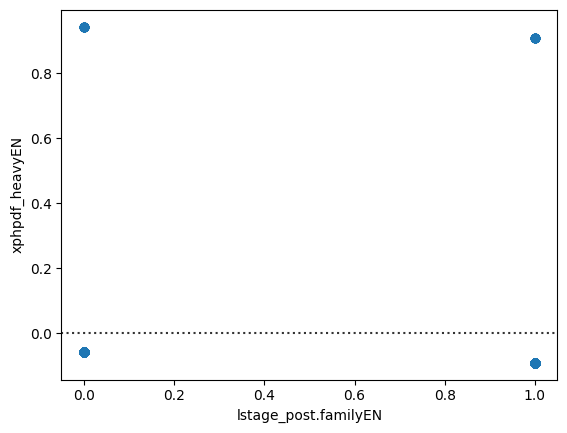

In [90]:
sns.residplot(x='lstage_post.familyEN', y='xphpdf_heavyEN', data=df) # residual plot

<Axes: xlabel='lstage_singleEN', ylabel='xphpdf_heavyEN'>

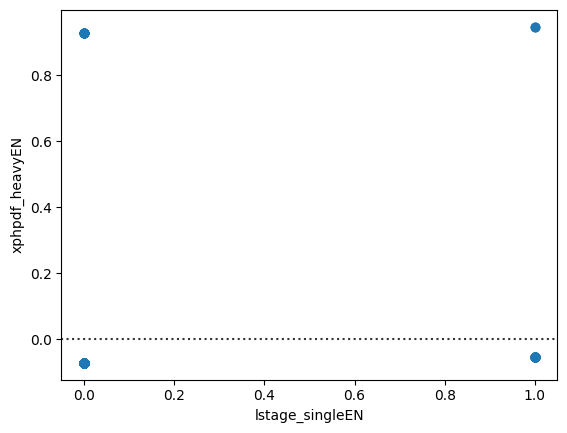

In [91]:
sns.residplot(x='lstage_singleEN', y='xphpdf_heavyEN', data=df) # residual plot

<Axes: xlabel='jbstathoh_retiredEN', ylabel='xphpdf_heavyEN'>

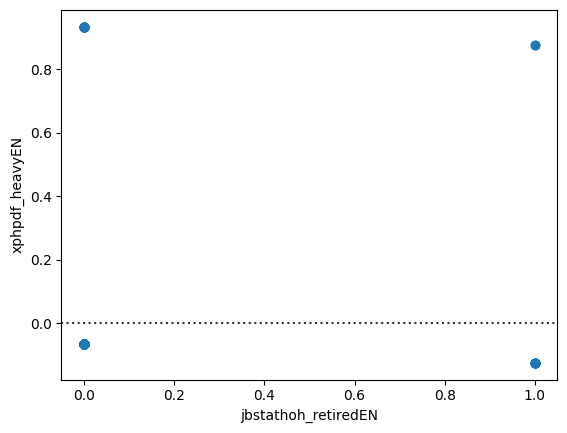

In [92]:
sns.residplot(x='jbstathoh_retiredEN', y='xphpdf_heavyEN', data=df) # residual plot

<Axes: xlabel='jbstat_retiredEN', ylabel='xphpdf_heavyEN'>

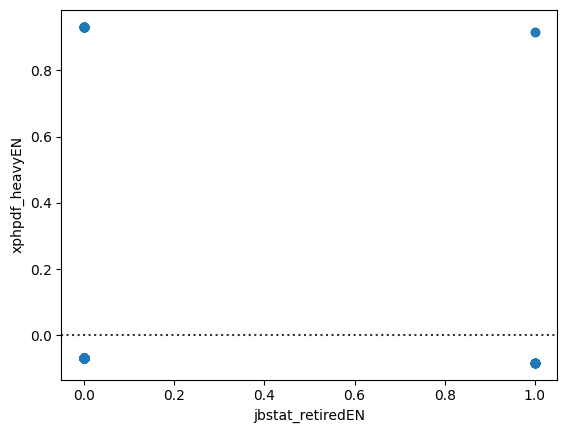

In [93]:
sns.residplot(x='jbstat_retiredEN', y='xphpdf_heavyEN', data=df) # residual plot

## k-fold cross-validation and data splitting

In [94]:
from sklearn.model_selection import cross_val_score, cross_val_predict

In [95]:
scores = cross_val_score(lm, X, Y, cv=6 )

returns an array of scores from cross-validation, where each score represents the performance of the model on a test fold, computed using the specified scoring metric

In [96]:
scores
#  Negative values are not an error — they are a design choice to standardize scoring.  The magnitude of the negative value indicates performance: closer to zero is better

array([0.92783505, 0.91752577, 0.92783505, 0.92783505, 0.91752577,
       0.92783505])

In [97]:
np.mean(scores)

np.float64(0.9243986254295534)

In [98]:
yhat = cross_val_predict(lm, X_test, y_test, cv=6 )

In [99]:
yhat

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

<Axes: xlabel='xphpdf_heavyEN'>

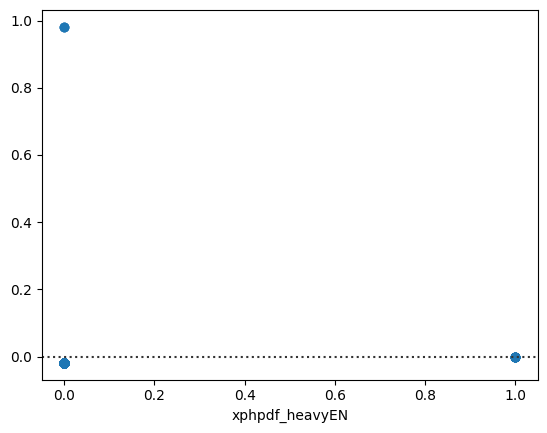

In [100]:
sns.residplot(x=y_test, y=yhat, data=df) # residual plot

## permutation_importance

Permutation importance measures how much a model's performance decreases when a single feature's values are randomly shuffled. 

Core idea: Shuffling a feature breaks its relationship with the target variable. If the model's performance drops significantly, the feature is important. 
Model-agnostic: Works with any model (e.g., random forests, neural networks). 
Computation: For each feature, the data is shuffled multiple times (n_repeats), and the average drop in model score (e.g., accuracy, R²) is recorded as its importance. 
Uses: Helps interpret models and identify key features, especially on held-out test data to reflect generalization. 
Limitation: Can underestimate importance for correlated features, as the model may rely on the correlated counterpart.

In [101]:
from sklearn.inspection import permutation_importance

C:\Users\ranun\AppData\Local\Temp\ipykernel_7092\1273366663.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(result.importances[sorted_idx].T, vert=False, labels=X.columns[sorted_idx])


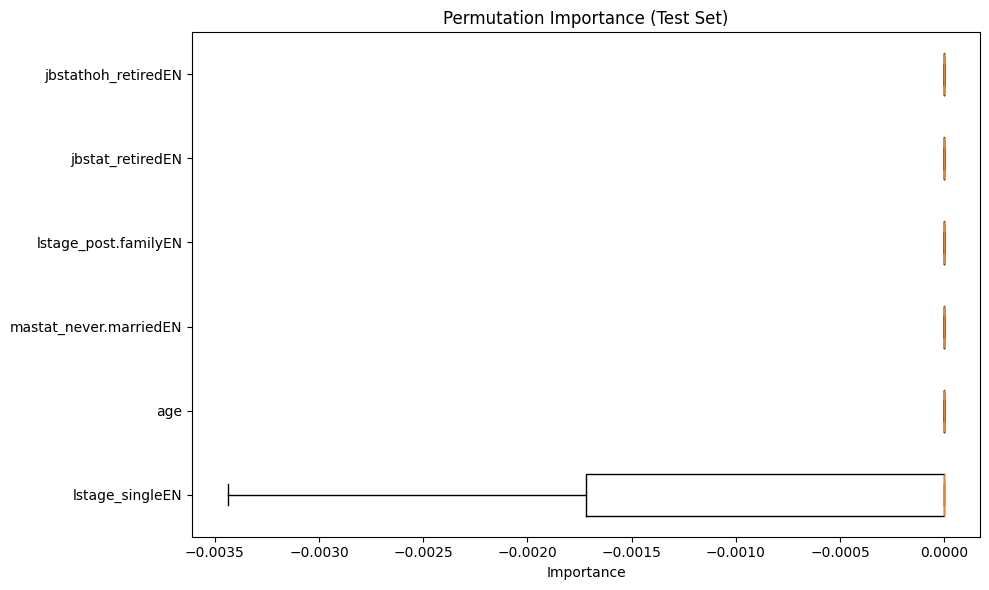

In [102]:
# Compute permutation importance
result = permutation_importance(lm, X, Y, n_repeats=10, random_state=42)

# Plot the results
sorted_idx = result.importances_mean.argsort()
plt.figure(figsize=(10, 6))
plt.boxplot(result.importances[sorted_idx].T, vert=False, labels=X.columns[sorted_idx])
plt.title("Permutation Importance (Test Set)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

## ROC Curve

 evaluate classification performance. These plots are valid and meaningful even when the training data contains NaNs, as long as the model was trained with HistGradientBoostingClassifier

AUC = 1.0*: Perfect classifier — correctly ranks all positive instances higher than negative ones. 
AUC > 0.9: Excellent performance. 
AUC between 0.8 and 0.9: Good performance. 
AUC between 0.7 and 0.8: Acceptable performance. 
AUC = 0.5: No discrimination ability — equivalent to random guessing (e.g., coin toss). 
AUC < 0.5: Worse than random — the model is performing poorly, possibly inverted predictions

In [103]:
from sklearn.metrics import roc_curve, auc
fpr, tpr, _ = roc_curve(y_test, yhat)  # Use the positive class score
roc_auc = auc(fpr, tpr)   

In [104]:
roc_auc

0.49074074074074076